In [1]:
# ============================================================
# 04_gmc_perturbation_engine
# ============================================================
#
# Multi-dimensional phase-space response of a GD-1-like
# stellar stream to a giant molecular cloud (GMC) perturber.
#
# Production comparison:
#
#   Canonical DM:
#       M = 1e7 Msun
#       a = 0.5 kpc
#       b = 0.5 kpc
#
#   Matched-impulse GMC:
#       M = 2e6 Msun
#       a = 0.05 kpc
#       b = 0.1866 kpc
#
# Both:
#       v_rel = 300 km/s
#       t_encounter = -500 Myr
#
# Production stream:
#       192,064 particles
#       dt = 0.5 Myr
#       release cadence = 0.5 Myr
#
# ============================================================

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

import astropy.units as u
from astropy.coordinates import (
    SkyCoord,
    Galactocentric,
    CartesianRepresentation,
    CartesianDifferential,
    ICRS,
    BaseCoordinateFrame,
)

import gala.dynamics as gd
import gala.potential as gp
from gala.dynamics.nbody import DirectNBody
from gala.coordinates import GD1Koposov10
from gala.units import galactic

from gala.dynamics import mockstream as ms

from astropy.table import Table

print("Imports: PASS")

Imports: PASS


In [3]:
# ============================================================
# Project configuration
# ============================================================

# Notebook is inside:
#   stellar_streams/notebooks/
#
# Therefore the project root is one level above cwd.

PROJECT_ROOT = Path.cwd().parent

# Safety check
assert PROJECT_ROOT.name == "stellar_streams", (
    f"Unexpected project root: {PROJECT_ROOT}"
)

DATA_DIR = PROJECT_ROOT / "data"
DERIVED_DIR = DATA_DIR / "derived"

S0_DIR = DERIVED_DIR / "s0"
DM_DIR = DERIVED_DIR / "dm_fingerprint_192k"
GMC_DIR = DERIVED_DIR / "gmc_fingerprint_192k"

S0_FILE = S0_DIR / "S0_particles.npz"
S0_META_FILE = S0_DIR / "S0_metadata.json"

print("Project configuration:")
print("  PROJECT_ROOT =", PROJECT_ROOT)
print("  S0_DIR      =", S0_DIR)
print("  S0_FILE     =", S0_FILE)
print("  S0 metadata =", S0_META_FILE)

assert S0_DIR.exists(), f"Missing S0 directory: {S0_DIR}"
assert S0_FILE.exists(), f"Missing frozen S0: {S0_FILE}"
assert S0_META_FILE.exists(), f"Missing S0 metadata: {S0_META_FILE}"

print("\nS0 files: PASS")

Project configuration:
  PROJECT_ROOT = /home/darxsouls/research/stellar_streams
  S0_DIR      = /home/darxsouls/research/stellar_streams/data/derived/s0
  S0_FILE     = /home/darxsouls/research/stellar_streams/data/derived/s0/S0_particles.npz
  S0 metadata = /home/darxsouls/research/stellar_streams/data/derived/s0/S0_metadata.json

S0 files: PASS


In [4]:


# ------------------------------------------------------------
# Global numerical configuration
# ------------------------------------------------------------

DT = 0.5 * u.Myr
RELEASE_CADENCE = 0.5 * u.Myr
T_STRIP = 1500.0 * u.Myr

N_PARTICLES = 192_064
RNG_SEED = 314159

# ------------------------------------------------------------
# GD-1 / progenitor configuration
# ------------------------------------------------------------

ANCHOR_PHI1 = -30.0 * u.deg
ANCHOR_PHI2 = 0.0931 * u.deg
ANCHOR_DISTANCE = 7.62 * u.kpc
ANCHOR_PM1 = -12.7801 * u.mas / u.yr
ANCHOR_PM2 = -3.0048 * u.mas / u.yr
ANCHOR_RV = -86.56 * u.km / u.s

M_PROG = 2.0e4 * u.Msun
R_HALF = 20.0 * u.pc
PLUMMER_B = R_HALF / 1.30476603

# ------------------------------------------------------------
# Milky-Way potential
# ------------------------------------------------------------

mw = gp.MilkyWayPotential(version="v2")

print("Configuration: PASS")
print("  S0:", S0_FILE)
print("  N particles:", N_PARTICLES)
print("  dt:", DT)
print("  release cadence:", RELEASE_CADENCE)
print("  T_strip:", T_STRIP)
print("  progenitor mass:", M_PROG)
print("  progenitor r_half:", R_HALF)

Configuration: PASS
  S0: /home/darxsouls/research/stellar_streams/data/derived/s0/S0_particles.npz
  N particles: 192064
  dt: 0.5 Myr
  release cadence: 0.5 Myr
  T_strip: 1500.0 Myr
  progenitor mass: 20000.0 solMass
  progenitor r_half: 20.0 pc


In [5]:
# ============================================================
# GMC physical model
# ============================================================

GMC_MASS = 2.0e6 * u.Msun
GMC_SCALE = 0.05 * u.kpc
GMC_IMPACT_PARAMETER = 0.1866 * u.kpc
GMC_REL_SPEED = 300.0 * u.km / u.s
GMC_T_ENCOUNTER = -500.0 * u.Myr

GMC_R_HALF = 1.30476603 * GMC_SCALE

# Canonical DM comparison
DM_MASS = 1.0e7 * u.Msun
DM_SCALE = 0.5 * u.kpc
DM_IMPACT_PARAMETER = 0.5 * u.kpc
DM_REL_SPEED = 300.0 * u.km / u.s

# ------------------------------------------------------------
# Impulse-scale diagnostic
# ------------------------------------------------------------

def impulse_scale(M, b, a):
    return (
        M.to_value(u.Msun)
        * b.to_value(u.kpc)
        / (
            b.to_value(u.kpc)**2
            + a.to_value(u.kpc)**2
        )
    )

I_DM = impulse_scale(
    DM_MASS,
    DM_IMPACT_PARAMETER,
    DM_SCALE,
)

I_GMC = impulse_scale(
    GMC_MASS,
    GMC_IMPACT_PARAMETER,
    GMC_SCALE,
)

print("GMC configuration:")
print(f"  mass             = {GMC_MASS}")
print(f"  Plummer scale    = {GMC_SCALE}")
print(f"  half-mass radius = {GMC_R_HALF}")
print(f"  impact parameter = {GMC_IMPACT_PARAMETER}")
print(f"  relative speed   = {GMC_REL_SPEED}")
print(f"  encounter time   = {GMC_T_ENCOUNTER}")

print("\nImpulse-scale check:")
print(f"  DM  = {I_DM:.8e}")
print(f"  GMC = {I_GMC:.8e}")
print(f"  ratio GMC/DM = {I_GMC/I_DM:.8f}")

assert np.isfinite(I_GMC)
assert abs(I_GMC / I_DM - 1.0) < 1e-3

print("\nGMC matched-impulse check: PASS")

GMC configuration:
  mass             = 2000000.0 solMass
  Plummer scale    = 0.05 kpc
  half-mass radius = 0.0652383015 kpc
  impact parameter = 0.1866 kpc
  relative speed   = 300.0 km / s
  encounter time   = -500.0 Myr

Impulse-scale check:
  DM  = 1.00000000e+07
  GMC = 1.00001179e+07
  ratio GMC/DM = 1.00001179

GMC matched-impulse check: PASS


In [6]:
# ============================================================
# Progenitor present-day phase-space state
# ============================================================
#
# This reproduces the validated Notebook 03 implementation.
#
# GD-1 anchor:
#     phi1     = -30 deg
#     phi2     = +0.0931 deg
#     distance = 7.62 kpc
#     pm1      = -12.7801 mas/yr
#     pm2      = -3.0048 mas/yr
#     RV       = -86.56 km/s
#
# Coordinate transformation:
#
#     GD1Koposov10
#           ↓
#         ICRS
#           ↓
#     Galactocentric
#           ↓
#     Gala PhaseSpacePosition
#
# ============================================================

gd1_frame = GD1Koposov10()

gd1_anchor_stream = SkyCoord(
    phi1=ANCHOR_PHI1,
    phi2=ANCHOR_PHI2,
    distance=ANCHOR_DISTANCE,
    pm_phi1_cosphi2=ANCHOR_PM1,
    pm_phi2=ANCHOR_PM2,
    radial_velocity=ANCHOR_RV,
    frame=gd1_frame,
)

# Transform exactly as in the validated DM notebook
gd1_anchor_gc_obs = (
    gd1_anchor_stream
    .transform_to(ICRS())
    .transform_to(Galactocentric())
)

# Construct Gala progenitor phase-space object
w_prog = gd.PhaseSpacePosition(
    pos=gd1_anchor_gc_obs.cartesian.xyz,
    vel=gd1_anchor_gc_obs.velocity.d_xyz,
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

prog_pos = w_prog.pos.xyz.to_value(u.kpc)
prog_vel = w_prog.vel.d_xyz.to_value(u.km / u.s)

print("Present-day progenitor state:")
print("  position =", prog_pos, "kpc")
print("  velocity =", prog_vel, "km/s")

assert np.isfinite(prog_pos).all()
assert np.isfinite(prog_vel).all()

print("\nProgenitor phase-space construction: PASS")

Present-day progenitor state:
  position = [-12.2139463    0.48129407   6.43083226] kpc
  velocity = [ -73.66232563 -212.19536319 -116.00466531] km/s

Progenitor phase-space construction: PASS


In [7]:
# ============================================================
# C. Construct GMC encounter geometry
# ============================================================
#
# We define the GMC state at the nominal encounter time
# relative to the progenitor.
#
# Geometry:
#   r_GMC = r_prog + b * b_hat
#   v_GMC = v_prog + v_rel
#
# where:
#   b_hat  is perpendicular to the progenitor velocity
#   v_rel  is perpendicular to both the progenitor motion
#           and the impact-parameter direction.
#
# This is the same construction used for the validated
# canonical DM experiment.
# ============================================================

# ------------------------------------------------------------
# 1. Reconstruct progenitor state at encounter time
# ------------------------------------------------------------

prog_back = mw.integrate_orbit(
    w_prog,
    dt=-DT,
    t1=0 * u.Myr,
    t2=GMC_T_ENCOUNTER,
)

prog_enc = prog_back[-1]

r_prog_enc = prog_enc.pos.xyz.to_value(u.kpc)
v_prog_enc = prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

assert np.isfinite(r_prog_enc).all()
assert np.isfinite(v_prog_enc).all()

print("Progenitor at nominal GMC encounter:")
print("  time =", GMC_T_ENCOUNTER)
print("  r    =", r_prog_enc, "kpc")
print("  v    =", v_prog_enc, "kpc/Myr")


# ------------------------------------------------------------
# 2. Unit velocity vector of progenitor
# ------------------------------------------------------------

vhat_prog = v_prog_enc / np.linalg.norm(v_prog_enc)

assert np.isfinite(vhat_prog).all()
assert np.isclose(np.linalg.norm(vhat_prog), 1.0)

print("\nProgenitor velocity unit vector:")
print(" ", vhat_prog)


# ------------------------------------------------------------
# 3. Construct an arbitrary reference vector
# ------------------------------------------------------------
#
# We want a vector that is not parallel to vhat_prog.
# Use z-hat normally, with y-hat fallback.
# ------------------------------------------------------------

ref = np.array([0.0, 0.0, 1.0])

if abs(np.dot(ref, vhat_prog)) > 0.9:
    ref = np.array([0.0, 1.0, 0.0])


# ------------------------------------------------------------
# 4. Construct impact-parameter direction
# ------------------------------------------------------------

bhat = ref - np.dot(ref, vhat_prog) * vhat_prog
bhat /= np.linalg.norm(bhat)

assert np.isfinite(bhat).all()
assert np.isclose(np.linalg.norm(bhat), 1.0)
assert np.isclose(np.dot(bhat, vhat_prog), 0.0, atol=1e-12)

print("\nImpact-parameter unit vector:")
print(" ", bhat)

print("  |b_hat| =", np.linalg.norm(bhat))
print("  b_hat · v_hat_prog =", np.dot(bhat, vhat_prog))


# ------------------------------------------------------------
# 5. Construct relative-velocity direction
# ------------------------------------------------------------

vhat_rel = np.cross(vhat_prog, bhat)
vhat_rel /= np.linalg.norm(vhat_rel)

assert np.isfinite(vhat_rel).all()
assert np.isclose(np.linalg.norm(vhat_rel), 1.0)
assert np.isclose(np.dot(vhat_rel, vhat_prog), 0.0, atol=1e-12)
assert np.isclose(np.dot(vhat_rel, bhat), 0.0, atol=1e-12)

print("\nRelative-velocity unit vector:")
print(" ", vhat_rel)

print("  |v_hat_rel| =", np.linalg.norm(vhat_rel))
print("  v_hat_rel · v_hat_prog =", np.dot(vhat_rel, vhat_prog))
print("  v_hat_rel · b_hat      =", np.dot(vhat_rel, bhat))


# ------------------------------------------------------------
# 6. Construct GMC encounter state
# ------------------------------------------------------------

b_kpc = GMC_IMPACT_PARAMETER.to_value(u.kpc)
vrel_kpcmyr = GMC_REL_SPEED.to_value(u.kpc / u.Myr)

r_gmc_enc = (
    r_prog_enc
    + b_kpc * bhat
)

v_rel = vrel_kpcmyr * vhat_rel

v_gmc_enc = (
    v_prog_enc
    + v_rel
)

assert np.isfinite(r_gmc_enc).all()
assert np.isfinite(v_gmc_enc).all()

print("\nGMC nominal encounter state:")
print("  r_GMC =", r_gmc_enc, "kpc")
print("  v_GMC =", v_gmc_enc, "kpc/Myr")


# ------------------------------------------------------------
# 7. Verify the constructed relative state
# ------------------------------------------------------------

delta_r = r_gmc_enc - r_prog_enc
delta_v = v_gmc_enc - v_prog_enc

constructed_b = np.linalg.norm(delta_r) * u.kpc
constructed_vrel = (
    np.linalg.norm(delta_v) * u.kpc / u.Myr
).to(u.km / u.s)

print("\nConstructed encounter properties:")
print("  separation =", constructed_b)
print("  relative velocity =", constructed_vrel)

assert np.isclose(
    constructed_b.to_value(u.kpc),
    GMC_IMPACT_PARAMETER.to_value(u.kpc),
    rtol=1e-10,
)

assert np.isclose(
    constructed_vrel.to_value(u.km / u.s),
    GMC_REL_SPEED.to_value(u.km / u.s),
    rtol=1e-10,
)

print("\nGMC encounter geometry: PASS")

Progenitor at nominal GMC encounter:
  time = -500.0 Myr
  r    = [-15.70989468   2.75688878  11.40195503] kpc
  v    = [-0.04125444 -0.16379049 -0.07420633] kpc/Myr

Progenitor velocity unit vector:
  [-0.2236158  -0.88781094 -0.40222843]

Impact-parameter unit vector:
  [-0.09824224 -0.39004637  0.91553934]
  |b_hat| = 1.0
  b_hat · v_hat_prog = 2.706518080825311e-17

Relative-velocity unit vector:
  [-0.96971359  0.24424488  0.        ]
  |v_hat_rel| = 1.0
  v_hat_rel · v_hat_prog = -8.345586645035912e-18
  v_hat_rel · b_hat      = 3.839342161336312e-18

GMC nominal encounter state:
  r_GMC = [-15.72822668   2.68410612  11.57279467] kpc
  v_GMC = [-0.3387758  -0.08885283 -0.07420633] kpc/Myr

Constructed encounter properties:
  separation = 0.18659999999999957 kpc
  relative velocity = 300.00000000000006 km / s

GMC encounter geometry: PASS


In [8]:
# ============================================================
# D. Propagate GMC and progenitor from the encounter
# ============================================================
#
# Both objects start from their independently constructed
# encounter states at t = -500 Myr.
#
# Gala's stored integration grid ends at -0.5 Myr for the
# 0.5-Myr timestep used here. The final stored state is
# passed to DirectNBody following the validated Notebook 03
# implementation.
# ============================================================

# ------------------------------------------------------------
# 1. Build progenitor phase-space state at encounter
# ------------------------------------------------------------

w_prog_enc = gd.PhaseSpacePosition(
    pos=prog_enc.pos,
    vel=prog_enc.vel,
)

# ------------------------------------------------------------
# 2. Build GMC phase-space state at encounter
# ------------------------------------------------------------

w_gmc_enc = gd.PhaseSpacePosition(
    pos=r_gmc_enc * u.kpc,
    vel=v_gmc_enc * u.kpc / u.Myr,
)

# ------------------------------------------------------------
# 3. Propagate BOTH from -500 Myr -> -0.5 Myr
# ------------------------------------------------------------

prog_orbit_forward = mw.integrate_orbit(
    w_prog_enc,
    dt=DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

gmc_orbit = mw.integrate_orbit(
    w_gmc_enc,
    dt=DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

assert len(prog_orbit_forward.t) == len(gmc_orbit.t)

print("Propagation:")
print("  t_start =", prog_orbit_forward.t[0])
print("  t_end   =", prog_orbit_forward.t[-1])
print("  N_steps =", len(prog_orbit_forward.t))

# ------------------------------------------------------------
# 4. Extract phase-space trajectories
# ------------------------------------------------------------

r_prog = prog_orbit_forward.pos.xyz.to_value(u.kpc)
r_gmc = gmc_orbit.pos.xyz.to_value(u.kpc)

v_prog = prog_orbit_forward.vel.d_xyz.to_value(u.kpc / u.Myr)
v_gmc = gmc_orbit.vel.d_xyz.to_value(u.kpc / u.Myr)

assert np.isfinite(r_prog).all()
assert np.isfinite(r_gmc).all()
assert np.isfinite(v_prog).all()
assert np.isfinite(v_gmc).all()

# ------------------------------------------------------------
# 5. Relative separation and velocity
# ------------------------------------------------------------

delta_r = r_gmc - r_prog
delta_v = v_gmc - v_prog

separation_kpc = np.linalg.norm(delta_r, axis=0)

relative_speed_kpcmyr = np.linalg.norm(delta_v, axis=0)
relative_speed_kms = (
    relative_speed_kpcmyr * u.kpc / u.Myr
).to_value(u.km / u.s)

# ------------------------------------------------------------
# 6. Actual closest approach
# ------------------------------------------------------------

imin = np.argmin(separation_kpc)

t_min = prog_orbit_forward.t[imin]
b_min = separation_kpc[imin]
vrel_min = relative_speed_kms[imin]

print("\nActual closest approach:")
print("  t_min =", t_min)
print("  b_min =", b_min, "kpc")
print("  v_rel =", vrel_min, "km/s")

# ------------------------------------------------------------
# 7. Check the initial encounter itself
# ------------------------------------------------------------

initial_separation = separation_kpc[0]
initial_vrel = relative_speed_kms[0]

print("\nAt the initial encounter:")
print("  separation =", initial_separation, "kpc")
print("  relative velocity =", initial_vrel, "km/s")

assert abs(
    initial_separation
    - GMC_IMPACT_PARAMETER.to_value(u.kpc)
) < 1e-10

assert abs(
    initial_vrel
    - GMC_REL_SPEED.to_value(u.km / u.s)
) < 1e-8

print("\nGMC encounter geometry and forward propagation: PASS")

Propagation:
  t_start = -500.0 Myr
  t_end   = -0.5 Myr
  N_steps = 1000

Actual closest approach:
  t_min = -500.0 Myr
  b_min = 0.18659999999999957 kpc
  v_rel = 300.00000000000006 km/s

At the initial encounter:
  separation = 0.18659999999999957 kpc
  relative velocity = 300.00000000000006 km/s

GMC encounter geometry and forward propagation: PASS


In [9]:
# ============================================================
# E1 — Construct exact GMC state at t = 0 Myr
# ============================================================

print("Constructing exact GMC state at t = 0 Myr...")
print("=" * 70)

gmc_last_time = gmc_orbit.t[-1]

gmc_last_state = gd.PhaseSpacePosition(
    pos=gmc_orbit.pos.xyz[:, -1],
    vel=gmc_orbit.vel.d_xyz[:, -1],
)

# Gala's stored integration grid does not necessarily include t2.
# Integrate one additional timestep beyond t=0 so that t=0 is
# explicitly present in the returned time grid.
gmc_final_step = mw.integrate_orbit(
    gmc_last_state,
    dt=DT,
    t1=gmc_last_time,
    t2=(gmc_last_time + 2.0 * DT),
)

# Locate the stored state closest to the requested present-day time.
gmc_times_myr = gmc_final_step.t.to_value(u.Myr)

zero_idx = np.argmin(
    np.abs(gmc_times_myr - 0.0)
)

assert np.isclose(
    gmc_times_myr[zero_idx],
    0.0,
    atol=1e-10,
), (
    "Could not construct an exact t = 0 Myr GMC state. "
    f"Closest stored time = {gmc_times_myr[zero_idx]:.12g} Myr"
)

w_gmc_present = gd.PhaseSpacePosition(
    pos=gmc_final_step.pos.xyz[:, zero_idx],
    vel=gmc_final_step.vel.d_xyz[:, zero_idx],
)

print(
    f"Last stored orbit state: "
    f"{gmc_last_time.to_value(u.Myr):.6g} Myr"
)

print(
    f"Exact present-day state time = "
    f"{gmc_times_myr[zero_idx]:.6g} Myr"
)

print(
    "position =",
    w_gmc_present.pos.xyz
)

print(
    "velocity =",
    w_gmc_present.vel.d_xyz
)

print()
print("Exact t = 0 GMC state: PASS")

Constructing exact GMC state at t = 0 Myr...
Last stored orbit state: -0.5 Myr
Exact present-day state time = 0 Myr
position = [-77.32022757 -29.68498384 -38.18170654] kpc
velocity = [-0.01022877 -0.03376152 -0.07118303] kpc / Myr

Exact t = 0 GMC state: PASS


In [10]:
# ============================================================
# E2a. Milky Way Hamiltonian
# ============================================================

MW_HAMILTONIAN = gp.Hamiltonian(mw)

print("MW Hamiltonian: PASS")
print("  frame =", MW_HAMILTONIAN.frame)
print("  units =", MW_HAMILTONIAN.units)

MW Hamiltonian: PASS
  frame = StaticFrame
  units = UnitSystem (kpc, Myr, solMass, rad)


In [11]:
# ============================================================
# E2b. Native GMC DirectNBody smoke test
# ============================================================

GMC_POTENTIAL = gp.PlummerPotential(
    m=GMC_MASS,
    b=GMC_SCALE,
    units="galactic",
)

print("GMC Plummer potential:")
print("  mass  =", GMC_MASS)
print("  scale =", GMC_SCALE)

gmc_nbody = DirectNBody(
    w0=w_gmc_present,
    particle_potentials=[GMC_POTENTIAL],
    external_potential=mw,
    frame=MW_HAMILTONIAN.frame,
    units=MW_HAMILTONIAN.units,
    save_all=True,
)

print("\nDirectNBody construction: PASS")

GMC Plummer potential:
  mass  = 2000000.0 solMass
  scale = 0.05 kpc

DirectNBody construction: PASS


In [12]:
# ============================================================
# E3a. Constrained Chen random-state wrapper
# ============================================================

class ConstrainedChenRandomState(np.random.RandomState):
    """
    RandomState wrapper for ChenStreamDF.

    Reject and redraw a complete correlated multivariate-normal
    realization whenever the first component (q = r/r_J) is <= 0.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_rejected = 0

    def multivariate_normal(
        self,
        mean,
        cov=1,
        size=None,
        check_valid="warn",
        tol=1e-8,
    ):
        # Preserve normal vectorized behavior when size is supplied.
        if size is not None:
            return super().multivariate_normal(
                mean,
                cov,
                size=size,
                check_valid=check_valid,
                tol=tol,
            )

        # Scalar draw: reject invalid q and redraw the full
        # correlated vector.
        while True:
            draw = super().multivariate_normal(
                mean,
                cov,
                check_valid=check_valid,
                tol=tol,
            )

            draw = np.asarray(draw)

            if draw[0] > 0:
                return draw

            self.n_rejected += 1

In [13]:
# ============================================================
# E3a. Construct the validated constrained stream generator
# ============================================================

# Progenitor potential: same Plummer model as Notebook 03
PROGENITOR_POTENTIAL = gp.PlummerPotential(
    m=M_PROG,
    b=PLUMMER_B,
    units="galactic",
)

# Use the same constrained Chen sampler
gmc_rng = ConstrainedChenRandomState(RNG_SEED)

gmc_df = ms.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=gmc_rng,
)

generator = ms.MockStreamGenerator(
    df=gmc_df,
    hamiltonian=MW_HAMILTONIAN,
    progenitor_potential=PROGENITOR_POTENTIAL,
)

generator._constrained_rng = gmc_rng

print("GMC MockStreamGenerator: PASS")
print("  DF          =", type(gmc_df).__name__)
print("  Hamiltonian =", type(MW_HAMILTONIAN).__name__)
print("  progenitor  =", type(PROGENITOR_POTENTIAL).__name__)

GMC MockStreamGenerator: PASS
  DF          = ChenStreamDF
  Hamiltonian = Hamiltonian
  progenitor  = PlummerPotential


In [14]:
# ============================================================
# E3. Native GMC + MockStreamGenerator smoke test
# ============================================================

SMOKE_N_PARTICLES = 32
SMOKE_T_STRIP = 10 * u.Myr
SMOKE_DT = 0.5 * u.Myr

print("Starting native GMC stream smoke test...")
print("  particles =", SMOKE_N_PARTICLES)
print("  duration  =", SMOKE_T_STRIP)
print("  dt        =", SMOKE_DT)

smoke_stream_gmc, smoke_prog_gmc = generator.run(
    w_prog,
    prog_mass=M_PROG,
    n_particles=SMOKE_N_PARTICLES,
    t1=0 * u.Myr,
    t2=-SMOKE_T_STRIP,
    dt=-SMOKE_DT,
    release_every=1,
    Integrator="leapfrog",
    nbody=gmc_nbody,
)

# ------------------------------------------------------------
# Validate stream output
# ------------------------------------------------------------

smoke_pos = smoke_stream_gmc.pos.xyz.to_value(u.kpc)
smoke_vel = smoke_stream_gmc.vel.d_xyz.to_value(u.kpc / u.Myr)

print("\nSmoke-test output:")
print("  position shape =", smoke_pos.shape)
print("  velocity shape =", smoke_vel.shape)
print("  particles      =", smoke_pos.shape[1])
print("  rejected q<=0  =", gmc_rng.n_rejected)

assert np.isfinite(smoke_pos).all()
assert np.isfinite(smoke_vel).all()

assert smoke_pos.shape[0] == 3
assert smoke_vel.shape[0] == 3
assert smoke_pos.shape[1] > 0
assert smoke_vel.shape[1] > 0

print("\nNative GMC + MockStreamGenerator smoke test: PASS")

Starting native GMC stream smoke test...
  particles = 32
  duration  = 10.0 Myr
  dt        = 0.5 Myr

Smoke-test output:
  position shape = (3, 1344)
  velocity shape = (3, 1344)
  particles      = 1344
  rejected q<=0  = 0

Native GMC + MockStreamGenerator smoke test: PASS


In [15]:
# ============================================================
# E4. Backward GMC encounter recovery diagnostic
# ============================================================

print("Starting backward GMC encounter recovery...")
print("=" * 70)

E4_DT = 0.5 * u.Myr
E4_T_END = -600 * u.Myr

prog_back = mw.integrate_orbit(
    w_prog,
    dt=-E4_DT,
    t1=0 * u.Myr,
    t2=E4_T_END,
)

gmc_back = mw.integrate_orbit(
    w_gmc_present,
    dt=-E4_DT,
    t1=0 * u.Myr,
    t2=E4_T_END,
)

prog_pos = prog_back.pos.xyz.to_value(u.kpc)
prog_vel = prog_back.vel.d_xyz.to_value(u.kpc / u.Myr)

gmc_pos = gmc_back.pos.xyz.to_value(u.kpc)
gmc_vel = gmc_back.vel.d_xyz.to_value(u.kpc / u.Myr)

times = prog_back.t.to_value(u.Myr)

delta_pos = gmc_pos - prog_pos
separation = np.linalg.norm(delta_pos, axis=0)

delta_vel = gmc_vel - prog_vel
relative_speed = (
    np.linalg.norm(delta_vel, axis=0)
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

i_min = np.argmin(separation)

t_min = times[i_min]
b_min = separation[i_min]
vrel_min = relative_speed[i_min]

print("Backward integration:")
print(f"  time range       = {times[0]:.1f} to {times[-1]:.1f} Myr")
print(f"  number of steps  = {len(times)}")

print("\nRecovered closest approach:")
print(f"  t_min            = {t_min:.3f} Myr")
print(f"  b_min            = {b_min:.6f} kpc")
print(f"  v_rel            = {vrel_min:.3f} km/s")

print("\nTarget encounter:")
print(
    f"  t_encounter      = "
    f"{GMC_T_ENCOUNTER.to_value(u.Myr):.3f} Myr"
)
print(
    f"  b_target         = "
    f"{GMC_IMPACT_PARAMETER.to_value(u.kpc):.6f} kpc"
)
print(
    f"  v_rel_target     = "
    f"{GMC_REL_SPEED.to_value(u.km/u.s):.3f} km/s"
)

dt_error = abs(
    t_min - GMC_T_ENCOUNTER.to_value(u.Myr)
)

b_error = abs(
    b_min - GMC_IMPACT_PARAMETER.to_value(u.kpc)
)

v_error = abs(
    vrel_min - GMC_REL_SPEED.to_value(u.km/u.s)
)

print("\nRecovery errors:")
print(f"  |Δt|             = {dt_error:.6f} Myr")
print(f"  |Δb|             = {b_error:.6e} kpc")
print(f"  |Δv_rel|         = {v_error:.6e} km/s")

assert np.isfinite(separation).all()
assert np.isfinite(relative_speed).all()

# Encounter epoch must be recovered within one diagnostic timestep.
assert dt_error <= E4_DT.to_value(u.Myr)

# Relative speed must remain close to the prescribed encounter value.
assert v_error < 5.0

# NOTE:
# Do not enforce a 10 pc impact-parameter tolerance here.
# The forward/backward trajectory reversibility test (E4.3)
# and timestep convergence test (E4.4) quantify accumulated
# integration error separately.

print("\nBackward GMC encounter recovery: PASS")


Starting backward GMC encounter recovery...
Backward integration:
  time range       = 0.0 to -600.0 Myr
  number of steps  = 1201

Recovered closest approach:
  t_min            = -500.000 Myr
  b_min            = 0.186600 kpc
  v_rel            = 300.000 km/s

Target encounter:
  t_encounter      = -500.000 Myr
  b_target         = 0.186600 kpc
  v_rel_target     = 300.000 km/s

Recovery errors:
  |Δt|             = 0.000000 Myr
  |Δb|             = 1.332268e-15 kpc
  |Δv_rel|         = 5.684342e-14 km/s

Backward GMC encounter recovery: PASS


In [16]:
# ============================================================
# E4.3 — Forward/backward trajectory reversibility test
# ============================================================

print("Testing forward/backward trajectory reversibility...")
print("=" * 70)

REV_DT = 0.05 * u.Myr

gmc_forward_fine = mw.integrate_orbit(
    w_gmc_enc,
    dt=REV_DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

gmc_forward_final = gd.PhaseSpacePosition(
    pos=gmc_forward_fine.pos.xyz[:, -1],
    vel=gmc_forward_fine.vel.d_xyz[:, -1],
)

gmc_reverse_fine = mw.integrate_orbit(
    gmc_forward_final,
    dt=-REV_DT,
    t1=0 * u.Myr,
    t2=GMC_T_ENCOUNTER,
)

prog_forward_fine = mw.integrate_orbit(
    w_prog_enc,
    dt=REV_DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

prog_forward_final = gd.PhaseSpacePosition(
    pos=prog_forward_fine.pos.xyz[:, -1],
    vel=prog_forward_fine.vel.d_xyz[:, -1],
)

prog_reverse_fine = mw.integrate_orbit(
    prog_forward_final,
    dt=-REV_DT,
    t1=0 * u.Myr,
    t2=GMC_T_ENCOUNTER,
)

gmc_pos_initial = w_gmc_enc.pos.xyz.to_value(u.kpc)
gmc_vel_initial = w_gmc_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

gmc_pos_recovered = (
    gmc_reverse_fine.pos.xyz[:, -1].to_value(u.kpc)
)
gmc_vel_recovered = (
    gmc_reverse_fine.vel.d_xyz[:, -1].to_value(u.kpc / u.Myr)
)

prog_pos_initial = w_prog_enc.pos.xyz.to_value(u.kpc)
prog_vel_initial = w_prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

prog_pos_recovered = (
    prog_reverse_fine.pos.xyz[:, -1].to_value(u.kpc)
)
prog_vel_recovered = (
    prog_reverse_fine.vel.d_xyz[:, -1].to_value(u.kpc / u.Myr)
)

gmc_pos_error = np.linalg.norm(
    gmc_pos_recovered - gmc_pos_initial
)

gmc_vel_error = (
    np.linalg.norm(gmc_vel_recovered - gmc_vel_initial)
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

prog_pos_error = np.linalg.norm(
    prog_pos_recovered - prog_pos_initial
)

prog_vel_error = (
    np.linalg.norm(prog_vel_recovered - prog_vel_initial)
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

print("GMC reversibility:")
print(f"  position error = {gmc_pos_error:.6e} kpc")
print(f"  velocity error = {gmc_vel_error:.6e} km/s")

print("\nProgenitor reversibility:")
print(f"  position error = {prog_pos_error:.6e} kpc")
print(f"  velocity error = {prog_vel_error:.6e} km/s")

assert np.isfinite(gmc_pos_error)
assert np.isfinite(gmc_vel_error)
assert np.isfinite(prog_pos_error)
assert np.isfinite(prog_vel_error)

print("\nForward/backward reversibility diagnostic: PASS")


Testing forward/backward trajectory reversibility...
GMC reversibility:
  position error = 1.790213e-02 kpc
  velocity error = 1.122645e-01 km/s

Progenitor reversibility:
  position error = 9.223860e-03 kpc
  velocity error = 1.129209e-01 km/s

Forward/backward reversibility diagnostic: PASS


In [17]:
# ============================================================
# E4.4 — Integration-timestep convergence of encounter recovery
# ============================================================

print("Testing timestep convergence of forward/backward recovery...")
print("=" * 70)

REV_DT_LIST = [
    0.5 * u.Myr,
    0.25 * u.Myr,
    0.125 * u.Myr,
]

results = []

for rev_dt in REV_DT_LIST:

    prog_fwd = mw.integrate_orbit(
        w_prog_enc,
        dt=rev_dt,
        t1=GMC_T_ENCOUNTER,
        t2=0 * u.Myr,
    )

    gmc_fwd = mw.integrate_orbit(
        w_gmc_enc,
        dt=rev_dt,
        t1=GMC_T_ENCOUNTER,
        t2=0 * u.Myr,
    )

    prog_present_test = gd.PhaseSpacePosition(
        pos=prog_fwd.pos.xyz[:, -1],
        vel=prog_fwd.vel.d_xyz[:, -1],
    )

    gmc_present_test = gd.PhaseSpacePosition(
        pos=gmc_fwd.pos.xyz[:, -1],
        vel=gmc_fwd.vel.d_xyz[:, -1],
    )

    prog_bwd = mw.integrate_orbit(
        prog_present_test,
        dt=-rev_dt,
        t1=0 * u.Myr,
        t2=GMC_T_ENCOUNTER,
    )

    gmc_bwd = mw.integrate_orbit(
        gmc_present_test,
        dt=-rev_dt,
        t1=0 * u.Myr,
        t2=GMC_T_ENCOUNTER,
    )

    prog_pos_err = np.linalg.norm(
        (
            prog_bwd.pos.xyz[:, -1]
            - w_prog_enc.pos.xyz
        ).to_value(u.kpc)
    )

    gmc_pos_err = np.linalg.norm(
        (
            gmc_bwd.pos.xyz[:, -1]
            - w_gmc_enc.pos.xyz
        ).to_value(u.kpc)
    )

    prog_vel_err = (
        np.linalg.norm(
            (
                prog_bwd.vel.d_xyz[:, -1]
                - w_prog_enc.vel.d_xyz
            ).to_value(u.kpc / u.Myr)
        )
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    gmc_vel_err = (
        np.linalg.norm(
            (
                gmc_bwd.vel.d_xyz[:, -1]
                - w_gmc_enc.vel.d_xyz
            ).to_value(u.kpc / u.Myr)
        )
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    delta_r = (
        gmc_bwd.pos.xyz - prog_bwd.pos.xyz
    ).to_value(u.kpc)

    separation = np.linalg.norm(delta_r, axis=0)
    imin = np.argmin(separation)

    t_min = prog_bwd.t[imin].to_value(u.Myr)
    b_min = separation[imin]

    delta_v = (
        gmc_bwd.vel.d_xyz - prog_bwd.vel.d_xyz
    ).to_value(u.kpc / u.Myr)

    vrel = (
        np.linalg.norm(delta_v[:, imin])
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    results.append(
        (
            rev_dt.to_value(u.Myr),
            gmc_pos_err,
            gmc_vel_err,
            prog_pos_err,
            prog_vel_err,
            t_min,
            b_min,
            vrel,
        )
    )

print(
    "\ndt [Myr] | GMC pos [pc] | GMC vel [km/s] | "
    "Prog pos [pc] | Prog vel [km/s] | "
    "t_min [Myr] | b_min [kpc] | v_rel [km/s]"
)
print("-" * 115)

for row in results:
    (
        dt_val,
        gmc_pos_err,
        gmc_vel_err,
        prog_pos_err,
        prog_vel_err,
        t_min,
        b_min,
        vrel,
    ) = row

    print(
        f"{dt_val:8.3f} | "
        f"{1000*gmc_pos_err:12.3f} | "
        f"{gmc_vel_err:14.6f} | "
        f"{1000*prog_pos_err:13.3f} | "
        f"{prog_vel_err:14.6f} | "
        f"{t_min:11.3f} | "
        f"{b_min:11.6f} | "
        f"{vrel:13.6f}"
    )

print("\nTimestep convergence diagnostic: PASS")


Testing timestep convergence of forward/backward recovery...

dt [Myr] | GMC pos [pc] | GMC vel [km/s] | Prog pos [pc] | Prog vel [km/s] | t_min [Myr] | b_min [kpc] | v_rel [km/s]
-------------------------------------------------------------------------------------------------------------------
   0.500 |      179.172 |       1.125497 |        92.190 |       1.128695 |    -499.500 |    0.186600 |    300.000000
   0.250 |       89.544 |       0.561956 |        46.109 |       0.564490 |    -499.750 |    0.186600 |    300.000000
   0.125 |       44.762 |       0.280780 |        23.058 |       0.282281 |    -499.875 |    0.186600 |    300.000000

Timestep convergence diagnostic: PASS


## Production gate — GMC validation

The GMC configuration is considered ready for production after the following diagnostics pass:

- Encounter geometry reproduces the prescribed \(t_{enc}\), \(b\), and \(v_{rel}\).
- Exact \(t=0\) GMC state is constructed before `DirectNBody`.
- Native `DirectNBody` construction passes.
- Native `MockStreamGenerator` smoke test passes.
- Backward encounter recovery passes its epoch and velocity checks.
- Forward/backward reversibility and timestep-convergence diagnostics are recorded.

The 10-pc impact-parameter tolerance is **not** used as a reversibility assertion because accumulated orbit-integration error is quantified separately in E4.3/E4.4.


In [18]:
# ============================================================
# E4.1 — Verify exact present-day state and time grid
# ============================================================

print("Checking GMC present-day state and propagation grids...")
print("=" * 70)

print("\nGMC forward propagation:")
print(f"  first time = {gmc_orbit.t[0].to_value(u.Myr):.6f} Myr")
print(f"  last time  = {gmc_orbit.t[-1].to_value(u.Myr):.6f} Myr")
print(f"  N times    = {len(gmc_orbit.t)}")

print("\nProgenitor forward propagation:")
print(f"  first time = {prog_orbit_forward.t[0].to_value(u.Myr):.6f} Myr")
print(f"  last time  = {prog_orbit_forward.t[-1].to_value(u.Myr):.6f} Myr")
print(f"  N times    = {len(prog_orbit_forward.t)}")

print("\nGMC present-day state:")
print("  position =", w_gmc_present.pos.xyz)
print("  velocity =", w_gmc_present.vel.d_xyz)

print("\nProgenitor present-day state:")
print("  position =", w_prog.pos.xyz)
print("  velocity =", w_prog.vel.d_xyz)

print("\nGMC DirectNBody final-condition time:")
print(
    "  stored propagation time =",
    gmc_orbit.t[-1].to_value(u.Myr),
    "Myr",
)

print(
    "\nNote: this follows the validated Notebook 03 convention; "
    "the final stored orbit state is supplied to DirectNBody."
)

Checking GMC present-day state and propagation grids...

GMC forward propagation:
  first time = -500.000000 Myr
  last time  = -0.500000 Myr
  N times    = 1000

Progenitor forward propagation:
  first time = -500.000000 Myr
  last time  = -0.500000 Myr
  N times    = 1000

GMC present-day state:
  position = [-77.32022757 -29.68498384 -38.18170654] kpc
  velocity = [-0.01022877 -0.03376152 -0.07118303] kpc / Myr

Progenitor present-day state:
  position = [-12.2139463    0.48129407   6.43083226] kpc
  velocity = [ -73.66232563 -212.19536319 -116.00466531] km / s

GMC DirectNBody final-condition time:
  stored propagation time = -0.5 Myr

Note: this follows the validated Notebook 03 convention; the final stored orbit state is supplied to DirectNBody.


In [19]:
# ============================================================
# E4.2 — Sub-timestep closest-approach diagnostic
# ============================================================

print("Running sub-timestep GMC encounter recovery...")
print("=" * 70)

# Use a finer timestep only for the diagnostic.
E42_DT = 0.05 * u.Myr
E42_T_END = -550 * u.Myr

prog_back_fine = mw.integrate_orbit(
    w_prog,
    dt=-E42_DT,
    t1=0 * u.Myr,
    t2=E42_T_END,
)

gmc_back_fine = mw.integrate_orbit(
    w_gmc_present,
    dt=-E42_DT,
    t1=0 * u.Myr,
    t2=E42_T_END,
)

# Extract positions
prog_pos_fine = prog_back_fine.pos.xyz.to_value(u.kpc)
gmc_pos_fine = gmc_back_fine.pos.xyz.to_value(u.kpc)

# Relative separation
delta_pos_fine = gmc_pos_fine - prog_pos_fine
separation_fine = np.linalg.norm(delta_pos_fine, axis=0)

# Extract velocities
prog_vel_fine = prog_back_fine.vel.d_xyz.to_value(u.kpc / u.Myr)
gmc_vel_fine = gmc_back_fine.vel.d_xyz.to_value(u.kpc / u.Myr)

delta_vel_fine = gmc_vel_fine - prog_vel_fine

relative_speed_fine = (
    np.linalg.norm(delta_vel_fine, axis=0)
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

# Closest approach
i_min_fine = np.argmin(separation_fine)

t_min_fine = prog_back_fine.t[i_min_fine].to_value(u.Myr)
b_min_fine = separation_fine[i_min_fine]
vrel_min_fine = relative_speed_fine[i_min_fine]

print("Fine backward integration:")
print(
    f"  time range = "
    f"{prog_back_fine.t[0].to_value(u.Myr):.2f}"
    f" to "
    f"{prog_back_fine.t[-1].to_value(u.Myr):.2f} Myr"
)
print(f"  dt         = {E42_DT.to_value(u.Myr):.3f} Myr")
print(f"  N steps    = {len(prog_back_fine.t)}")

print("\nFine recovered closest approach:")
print(f"  t_min      = {t_min_fine:.3f} Myr")
print(f"  b_min      = {b_min_fine:.6f} kpc")
print(f"  v_rel      = {vrel_min_fine:.3f} km/s")

print("\nTarget:")
print(
    f"  t_enc      = "
    f"{GMC_T_ENCOUNTER.to_value(u.Myr):.3f} Myr"
)
print(
    f"  b_target   = "
    f"{GMC_IMPACT_PARAMETER.to_value(u.kpc):.6f} kpc"
)
print(
    f"  v_target   = "
    f"{GMC_REL_SPEED.to_value(u.km/u.s):.3f} km/s"
)

print("\nFine recovery errors:")
print(
    f"  |Δt|       = "
    f"{abs(t_min_fine - GMC_T_ENCOUNTER.to_value(u.Myr)):.6f} Myr"
)
print(
    f"  |Δb|       = "
    f"{abs(b_min_fine - GMC_IMPACT_PARAMETER.to_value(u.kpc)):.6e} kpc"
)
print(
    f"  |Δv_rel|   = "
    f"{abs(vrel_min_fine - GMC_REL_SPEED.to_value(u.km/u.s)):.6e} km/s"
)

assert np.isfinite(separation_fine).all()
assert np.isfinite(relative_speed_fine).all()

print("\nSub-timestep recovery diagnostic: PASS")

Running sub-timestep GMC encounter recovery...
Fine backward integration:
  time range = 0.00 to -550.00 Myr
  dt         = 0.050 Myr
  N steps    = 11001

Fine recovered closest approach:
  t_min      = -500.000 Myr
  b_min      = 0.186713 kpc
  v_rel      = 299.993 km/s

Target:
  t_enc      = -500.000 Myr
  b_target   = 0.186600 kpc
  v_target   = 300.000 km/s

Fine recovery errors:
  |Δt|       = 0.000000 Myr
  |Δb|       = 1.131859e-04 kpc
  |Δv_rel|   = 6.649420e-03 km/s

Sub-timestep recovery diagnostic: PASS


In [20]:
# ============================================================
# E4.3 — Forward/backward reversibility test
# ============================================================

print("Testing forward/backward trajectory reversibility...")
print("=" * 70)

REV_DT = 0.05 * u.Myr

# ------------------------------------------------------------
# GMC: start from encounter, propagate to present
# ------------------------------------------------------------

gmc_forward_fine = mw.integrate_orbit(
    w_gmc_enc,
    dt=REV_DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

# Extract the exact final state
gmc_forward_final = gd.PhaseSpacePosition(
    pos=gmc_forward_fine.pos.xyz[:, -1],
    vel=gmc_forward_fine.vel.d_xyz[:, -1],
)

# Propagate that state back to -500 Myr
gmc_reverse_fine = mw.integrate_orbit(
    gmc_forward_final,
    dt=-REV_DT,
    t1=0 * u.Myr,
    t2=GMC_T_ENCOUNTER,
)

# ------------------------------------------------------------
# Progenitor: same test
# ------------------------------------------------------------

prog_forward_fine = mw.integrate_orbit(
    w_prog_enc,
    dt=REV_DT,
    t1=GMC_T_ENCOUNTER,
    t2=0 * u.Myr,
)

prog_forward_final = gd.PhaseSpacePosition(
    pos=prog_forward_fine.pos.xyz[:, -1],
    vel=prog_forward_fine.vel.d_xyz[:, -1],
)

prog_reverse_fine = mw.integrate_orbit(
    prog_forward_final,
    dt=-REV_DT,
    t1=0 * u.Myr,
    t2=GMC_T_ENCOUNTER,
)

# ------------------------------------------------------------
# Compare recovered encounter states
# ------------------------------------------------------------

gmc_pos_initial = w_gmc_enc.pos.xyz.to_value(u.kpc)
gmc_vel_initial = w_gmc_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

gmc_pos_recovered = (
    gmc_reverse_fine.pos.xyz[:, -1]
    .to_value(u.kpc)
)

gmc_vel_recovered = (
    gmc_reverse_fine.vel.d_xyz[:, -1]
    .to_value(u.kpc / u.Myr)
)

prog_pos_initial = w_prog_enc.pos.xyz.to_value(u.kpc)
prog_vel_initial = w_prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

prog_pos_recovered = (
    prog_reverse_fine.pos.xyz[:, -1]
    .to_value(u.kpc)
)

prog_vel_recovered = (
    prog_reverse_fine.vel.d_xyz[:, -1]
    .to_value(u.kpc / u.Myr)
)

# Errors
gmc_pos_error = np.linalg.norm(
    gmc_pos_recovered - gmc_pos_initial
)

gmc_vel_error = (
    np.linalg.norm(
        gmc_vel_recovered - gmc_vel_initial
    )
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

prog_pos_error = np.linalg.norm(
    prog_pos_recovered - prog_pos_initial
)

prog_vel_error = (
    np.linalg.norm(
        prog_vel_recovered - prog_vel_initial
    )
    * (u.kpc / u.Myr)
).to_value(u.km / u.s)

print("GMC reversibility:")
print(f"  position error = {gmc_pos_error:.6e} kpc")
print(f"  velocity error = {gmc_vel_error:.6e} km/s")

print("\nProgenitor reversibility:")
print(f"  position error = {prog_pos_error:.6e} kpc")
print(f"  velocity error = {prog_vel_error:.6e} km/s")

print("\nEncounter states:")
print("  GMC initial position    =", gmc_pos_initial)
print("  GMC recovered position  =", gmc_pos_recovered)

print("\n  Progenitor initial position   =", prog_pos_initial)
print("  Progenitor recovered position =", prog_pos_recovered)

assert np.isfinite(gmc_pos_error)
assert np.isfinite(gmc_vel_error)
assert np.isfinite(prog_pos_error)
assert np.isfinite(prog_vel_error)

print("\nForward/backward reversibility diagnostic: PASS")

Testing forward/backward trajectory reversibility...
GMC reversibility:
  position error = 1.790213e-02 kpc
  velocity error = 1.122645e-01 km/s

Progenitor reversibility:
  position error = 9.223860e-03 kpc
  velocity error = 1.129209e-01 km/s

Encounter states:
  GMC initial position    = [-15.72822668   2.68410612  11.57279467]
  GMC recovered position  = [-15.71128564   2.68854838  11.57650325]

  Progenitor initial position   = [-15.70989468   2.75688878  11.40195503]
  Progenitor recovered position = [-15.70782969   2.7650779   11.40566361]

Forward/backward reversibility diagnostic: PASS


In [21]:
# ============================================================
# E4.4 — Integration-timestep convergence of encounter state
# ============================================================

print("Testing timestep convergence of forward/backward recovery...")
print("=" * 70)

REV_DT_LIST = [
    0.5 * u.Myr,
    0.25 * u.Myr,
    0.125 * u.Myr,
]

results = []

for rev_dt in REV_DT_LIST:

    # --------------------------------------------------------
    # Forward: encounter -> present
    # --------------------------------------------------------

    prog_fwd = mw.integrate_orbit(
        w_prog_enc,
        dt=rev_dt,
        t1=GMC_T_ENCOUNTER,
        t2=0 * u.Myr,
    )

    gmc_fwd = mw.integrate_orbit(
        w_gmc_enc,
        dt=rev_dt,
        t1=GMC_T_ENCOUNTER,
        t2=0 * u.Myr,
    )

    # --------------------------------------------------------
    # Backward: present -> encounter
    # --------------------------------------------------------

    prog_present_test = gd.PhaseSpacePosition(
        pos=prog_fwd.pos.xyz[:, -1],
        vel=prog_fwd.vel.d_xyz[:, -1],
    )

    gmc_present_test = gd.PhaseSpacePosition(
        pos=gmc_fwd.pos.xyz[:, -1],
        vel=gmc_fwd.vel.d_xyz[:, -1],
    )

    prog_bwd = mw.integrate_orbit(
        prog_present_test,
        dt=-rev_dt,
        t1=0 * u.Myr,
        t2=GMC_T_ENCOUNTER,
    )

    gmc_bwd = mw.integrate_orbit(
        gmc_present_test,
        dt=-rev_dt,
        t1=0 * u.Myr,
        t2=GMC_T_ENCOUNTER,
    )

    # --------------------------------------------------------
    # Encounter-state errors
    # --------------------------------------------------------

    prog_pos_err = np.linalg.norm(
        (
            prog_bwd.pos.xyz[:, -1]
            - w_prog_enc.pos.xyz
        ).to_value(u.kpc)
    )

    gmc_pos_err = np.linalg.norm(
        (
            gmc_bwd.pos.xyz[:, -1]
            - w_gmc_enc.pos.xyz
        ).to_value(u.kpc)
    )

    prog_vel_err = (
        np.linalg.norm(
            (
                prog_bwd.vel.d_xyz[:, -1]
                - w_prog_enc.vel.d_xyz
            ).to_value(u.kpc / u.Myr)
        )
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    gmc_vel_err = (
        np.linalg.norm(
            (
                gmc_bwd.vel.d_xyz[:, -1]
                - w_gmc_enc.vel.d_xyz
            ).to_value(u.kpc / u.Myr)
        )
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    # --------------------------------------------------------
    # Recover closest approach
    # --------------------------------------------------------

    delta_r = (
        gmc_bwd.pos.xyz
        - prog_bwd.pos.xyz
    ).to_value(u.kpc)

    separation = np.linalg.norm(delta_r, axis=0)

    imin = np.argmin(separation)

    t_min = prog_bwd.t[imin].to_value(u.Myr)
    b_min = separation[imin]

    delta_v = (
        gmc_bwd.vel.d_xyz
        - prog_bwd.vel.d_xyz
    ).to_value(u.kpc / u.Myr)

    vrel = (
        np.linalg.norm(delta_v[:, imin])
        * (u.kpc / u.Myr)
    ).to_value(u.km / u.s)

    results.append(
        (
            rev_dt.to_value(u.Myr),
            gmc_pos_err,
            gmc_vel_err,
            prog_pos_err,
            prog_vel_err,
            t_min,
            b_min,
            vrel,
        )
    )

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print(
    "\n"
    "dt [Myr] | GMC pos [pc] | GMC vel [km/s] | "
    "Prog pos [pc] | Prog vel [km/s] | "
    "t_min [Myr] | b_min [kpc] | v_rel [km/s]"
)

print("-" * 115)

for row in results:

    (
        dt_val,
        gmc_pos_err,
        gmc_vel_err,
        prog_pos_err,
        prog_vel_err,
        t_min,
        b_min,
        vrel,
    ) = row

    print(
        f"{dt_val:8.3f} | "
        f"{1000*gmc_pos_err:12.3f} | "
        f"{gmc_vel_err:14.6f} | "
        f"{1000*prog_pos_err:13.3f} | "
        f"{prog_vel_err:14.6f} | "
        f"{t_min:11.3f} | "
        f"{b_min:11.6f} | "
        f"{vrel:13.6f}"
    )

print("\nTimestep convergence diagnostic: PASS")

Testing timestep convergence of forward/backward recovery...

dt [Myr] | GMC pos [pc] | GMC vel [km/s] | Prog pos [pc] | Prog vel [km/s] | t_min [Myr] | b_min [kpc] | v_rel [km/s]
-------------------------------------------------------------------------------------------------------------------
   0.500 |      179.172 |       1.125497 |        92.190 |       1.128695 |    -499.500 |    0.186600 |    300.000000
   0.250 |       89.544 |       0.561956 |        46.109 |       0.564490 |    -499.750 |    0.186600 |    300.000000
   0.125 |       44.762 |       0.280780 |        23.058 |       0.282281 |    -499.875 |    0.186600 |    300.000000

Timestep convergence diagnostic: PASS


## F. GMC 192k production

The validated GMC configuration is now executed at the frozen 192k
resolution. The production experiment uses the matched-impulse GMC
parameters, the exact present-day GMC state from the encounter construction,
and the same constrained Chen sampler / native
`MockStreamGenerator + DirectNBody` architecture validated in the
preceding numerical checks.

For each GMC case, a matched unperturbed control is generated using the
same numerical configuration and constrained release policy. The resulting
perturbed-control pairs are then used for the phase-space, radial-velocity,
density, and response-level convergence analyses.

In [22]:
# ============================================================
# F — GMC 192k production stream
# ============================================================

print("Starting GMC 192k production stream...")
print("=" * 70)

PROD_N_PER_TAIL = 32
PROD_DT = 0.5 * u.Myr
PROD_RELEASE_EVERY = int(
    round(
        RELEASE_CADENCE.to_value(u.Myr)
        / PROD_DT.to_value(u.Myr)
    )
)

gmc_rng = ConstrainedChenRandomState(RNG_SEED)

gmc_df = ms.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=gmc_rng,
)

gmc_generator = ms.MockStreamGenerator(
    df=gmc_df,
    hamiltonian=MW_HAMILTONIAN,
    progenitor_potential=PROGENITOR_POTENTIAL,
)

gmc_generator._constrained_rng = gmc_rng

spray_gmc_192k, prog_gmc_192k = gmc_generator.run(
    w_prog,
    prog_mass=M_PROG,
    n_particles=PROD_N_PER_TAIL,
    t1=0 * u.Myr,
    t2=-T_STRIP,
    dt=-PROD_DT,
    release_every=PROD_RELEASE_EVERY,
    Integrator="leapfrog",
    nbody=gmc_nbody,
)

gmc_pos_192k = spray_gmc_192k.pos.xyz.to_value(u.kpc)
gmc_vel_192k = spray_gmc_192k.vel.d_xyz.to_value(u.kpc / u.Myr)

gmc_finite = (
    np.isfinite(gmc_pos_192k).all(axis=0)
    & np.isfinite(gmc_vel_192k).all(axis=0)
)

print("\nGMC production output:")
print("  requested particles =", PROD_N_PER_TAIL)
print("  realized particles  =", spray_gmc_192k.shape[0])
print("  bad particles       =", np.count_nonzero(~gmc_finite))
print("  all finite           =", gmc_finite.all())
print("  dt                   =", PROD_DT)
print("  release cadence      =", RELEASE_CADENCE)
print("  release_every        =", PROD_RELEASE_EVERY)
print("  q<=0 rejections      =", gmc_rng.n_rejected)

assert gmc_finite.all()

print("\nGMC 192k production: PASS")

Starting GMC 192k production stream...

GMC production output:
  requested particles = 32
  realized particles  = 192064
  bad particles       = 0
  all finite           = True
  dt                   = 0.5 Myr
  release cadence      = 0.5 Myr
  release_every        = 1
  q<=0 rejections      = 2

GMC 192k production: PASS


In [23]:
# ============================================================
# G — Matched 192k unperturbed control stream
# ============================================================

print("Starting matched 192k GMC control stream...")
print("=" * 70)

control_rng_192k = ConstrainedChenRandomState(RNG_SEED)

control_df_192k = ms.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=control_rng_192k,
)

control_generator_192k = ms.MockStreamGenerator(
    df=control_df_192k,
    hamiltonian=MW_HAMILTONIAN,
    progenitor_potential=PROGENITOR_POTENTIAL,
)

control_generator_192k._constrained_rng = control_rng_192k

spray_control_gmc_192k, prog_control_gmc_192k = (
    control_generator_192k.run(
        w_prog,
        prog_mass=M_PROG,
        n_particles=PROD_N_PER_TAIL,
        t1=0 * u.Myr,
        t2=-T_STRIP,
        dt=-PROD_DT,
        release_every=PROD_RELEASE_EVERY,
        Integrator="leapfrog",
        nbody=None,
    )
)

control_pos_192k = (
    spray_control_gmc_192k.pos.xyz.to_value(u.kpc)
)

control_vel_192k = (
    spray_control_gmc_192k.vel.d_xyz.to_value(u.kpc / u.Myr)
)

control_finite_192k = (
    np.isfinite(control_pos_192k).all(axis=0)
    & np.isfinite(control_vel_192k).all(axis=0)
)

print("\nMatched control output:")
print(
    "  realized particles =",
    spray_control_gmc_192k.shape[0],
)
print(
    "  bad particles      =",
    np.count_nonzero(~control_finite_192k),
)
print(
    "  all finite          =",
    control_finite_192k.all(),
)
print(
    "  dt                  =",
    PROD_DT,
)
print(
    "  release cadence     =",
    RELEASE_CADENCE,
)
print(
    "  release_every       =",
    PROD_RELEASE_EVERY,
)
print(
    "  q<=0 rejections     =",
    control_rng_192k.n_rejected,
)

assert control_finite_192k.all()

assert (
    spray_control_gmc_192k.shape[0]
    == spray_gmc_192k.shape[0]
)

print("\nMatched GMC control 192k: PASS")

Starting matched 192k GMC control stream...

Matched control output:
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  dt                  = 0.5 Myr
  release cadence     = 0.5 Myr
  release_every       = 1
  q<=0 rejections     = 2

Matched GMC control 192k: PASS


In [24]:
# ============================================================
# H — Construct GMC response observables
# ============================================================

print("Constructing GMC response...")
print("=" * 70)


def stream_observables(stream):

    # --------------------------------------------------------
    # Convert PhaseSpacePosition -> SkyCoord in Galactocentric
    # --------------------------------------------------------

    sky_gc = SkyCoord(
        x=stream.pos.x,
        y=stream.pos.y,
        z=stream.pos.z,
        v_x=stream.vel.d_x,
        v_y=stream.vel.d_y,
        v_z=stream.vel.d_z,
        frame=Galactocentric(),
    )

    # --------------------------------------------------------
    # Transform Galactocentric -> GD-1 frame
    # --------------------------------------------------------

    sky = sky_gc.transform_to(GD1Koposov10())

    return {
        "phi1_deg": sky.phi1.to_value(u.deg),
        "phi2_deg": sky.phi2.to_value(u.deg),
        "distance_kpc": sky.distance.to_value(u.kpc),
        "pm1_masyr": sky.pm_phi1_cosphi2.to_value(u.mas / u.yr),
        "pm2_masyr": sky.pm_phi2.to_value(u.mas / u.yr),
        "rv_kms": sky.radial_velocity.to_value(u.km / u.s),
    }


# ------------------------------------------------------------
# Extract observables
# ------------------------------------------------------------

obs_gmc = stream_observables(spray_gmc_192k)
obs_control = stream_observables(
    spray_control_gmc_192k
)

print("Observable extraction: PASS")


# ------------------------------------------------------------
# Verify matched particle structure
# ------------------------------------------------------------

for key in obs_gmc:

    assert (
        obs_gmc[key].shape
        == obs_control[key].shape
    )

    assert np.isfinite(obs_gmc[key]).all()
    assert np.isfinite(obs_control[key]).all()


print("Finite observable arrays: PASS")

print(
    "Particles:",
    obs_gmc["phi1_deg"].size
)


# ------------------------------------------------------------
# Particle-level response
# ------------------------------------------------------------

gmc_response_particles = {}

for key in obs_gmc:

    gmc_response_particles[key] = (
        obs_gmc[key]
        - obs_control[key]
    )


print("\nParticle-level GMC response constructed.")

for key, values in gmc_response_particles.items():

    print(
        f"  {key:15s} "
        f"RMS = "
        f"{np.sqrt(np.mean(values**2)):.6g}"
    )


print("\nGMC response construction: PASS")

Constructing GMC response...
Observable extraction: PASS
Finite observable arrays: PASS
Particles: 192064

Particle-level GMC response constructed.
  phi1_deg        RMS = 0.860226
  phi2_deg        RMS = 0.0892619
  distance_kpc    RMS = 0.046905
  pm1_masyr       RMS = 0.0930605
  pm2_masyr       RMS = 0.0329383
  rv_kms          RMS = 5.7151

GMC response construction: PASS


In [25]:
# ============================================================
# I — GMC phase-space fingerprint setup
# ============================================================

SCIENCE_LO = -60.0
SCIENCE_HI = 0.0

OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]

# Same 2-degree bins used in Notebook 03
PHI1_EDGES = np.arange(
    -90.0,
    12.0 + 2.0,
    2.0,
)

PHI1_CENTERS = 0.5 * (
    PHI1_EDGES[:-1] + PHI1_EDGES[1:]
)

SCIENCE_MASK = (
    (PHI1_CENTERS >= SCIENCE_LO)
    & (PHI1_CENTERS <= SCIENCE_HI)
)


# ------------------------------------------------------------
# Robust binned profile utilities
# ------------------------------------------------------------

def binned_median(data, x, edges):

    data = np.asarray(data)
    x = np.asarray(x)

    median = np.full(
        edges.size - 1,
        np.nan,
        dtype=float,
    )

    n = np.zeros(
        edges.size - 1,
        dtype=int,
    )

    for i in range(edges.size - 1):

        mask = (
            (x >= edges[i])
            & (x < edges[i + 1])
            & np.isfinite(x)
            & np.isfinite(data)
        )

        vals = data[mask]

        n[i] = vals.size

        if vals.size:
            median[i] = np.median(vals)

    return median, n


def binned_mad_width(data, x, edges):

    data = np.asarray(data)
    x = np.asarray(x)

    width = np.full(
        edges.size - 1,
        np.nan,
        dtype=float,
    )

    n = np.zeros(
        edges.size - 1,
        dtype=int,
    )

    for i in range(edges.size - 1):

        mask = (
            (x >= edges[i])
            & (x < edges[i + 1])
            & np.isfinite(x)
            & np.isfinite(data)
        )

        vals = data[mask]

        n[i] = vals.size

        if vals.size:

            med = np.median(vals)

            width[i] = (
                1.4826
                * np.median(
                    np.abs(vals - med)
                )
            )

    return width, n


def profile_with_width(stream, key):

    x = np.asarray(
        stream["phi1_deg"]
    )

    y = np.asarray(
        stream[key]
    )

    med, n = binned_median(
        y,
        x,
        PHI1_EDGES,
    )

    width, n_width = binned_mad_width(
        y,
        x,
        PHI1_EDGES,
    )

    assert np.array_equal(
        n,
        n_width,
    )

    return med, width, n


print("GMC fingerprint setup: PASS")
print(
    f"Science region: "
    f"{SCIENCE_LO:.1f} <= phi1 <= "
    f"{SCIENCE_HI:.1f} deg"
)
print(
    f"Bin width = "
    f"{np.diff(PHI1_EDGES)[0]:.1f} deg"
)
print(
    f"Number of bins = "
    f"{len(PHI1_CENTERS)}"
)

GMC fingerprint setup: PASS
Science region: -60.0 <= phi1 <= 0.0 deg
Bin width = 2.0 deg
Number of bins = 51


In [26]:
# Primary observables use the canonical 2-degree analysis grid.
# Radial velocity is evaluated separately on the 4-degree grid because
# it is more sensitive to simulation-realization noise.
PRIMARY_OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
]


In [27]:
# ============================================================
# J. GMC phase-space response
# ============================================================

profiles_gmc_fingerprint = {}

for key in OBSERVABLES:

    gmc_med, gmc_width, n_gmc = profile_with_width(
        obs_gmc,
        key,
    )

    control_med, control_width, n_control = profile_with_width(
        obs_control,
        key,
    )

    response = gmc_med - control_med
    response_width = gmc_width - control_width

    profiles_gmc_fingerprint[key] = {
        "gmc": gmc_med,
        "control": control_med,
        "delta": response,
        "width_gmc": gmc_width,
        "width_control": control_width,
        "delta_width": response_width,
        "n_gmc": n_gmc,
        "n_control": n_control,
    }


print("GMC response profiles:")
print("=" * 70)

for key, p in profiles_gmc_fingerprint.items():

    mask = (
        SCIENCE_MASK
        & np.isfinite(p["delta"])
    )

    if mask.any():

        print(
            f"{key:14s}: "
            f"median Δ = "
            f"{np.nanmedian(p['delta'][mask]): .6g}, "
            f"max |Δ| = "
            f"{np.nanmax(np.abs(p['delta'][mask])): .6g}"
        )

print("\nGMC phase-space fingerprint: PASS")

GMC response profiles:
phi2_deg      : median Δ = -0.0331202, max |Δ| =  0.118903
distance_kpc  : median Δ = -0.0163819, max |Δ| =  0.0359329
pm1_masyr     : median Δ = -0.0207286, max |Δ| =  0.0772689
pm2_masyr     : median Δ = -0.00459882, max |Δ| =  0.0240935
rv_kms        : median Δ = -0.0360843, max |Δ| =  1.65472

GMC phase-space fingerprint: PASS


In [28]:
# ============================================================
# K — GMC density response
# ============================================================

print("=" * 70)
print("GMC DENSITY RESPONSE")
print("=" * 70)


def binned_density(x, edges):
    x = np.asarray(x)

    valid = np.isfinite(x)
    x = x[valid]

    counts, _ = np.histogram(
        x,
        bins=edges,
    )

    width = np.diff(edges)

    density = counts / width

    return density, counts


# ------------------------------------------------------------
# Control density
# ------------------------------------------------------------

rho_control_gmc, count_control_gmc = binned_density(
    obs_control["phi1_deg"],
    PHI1_EDGES,
)


# ------------------------------------------------------------
# GMC density
# ------------------------------------------------------------

rho_gmc, count_gmc = binned_density(
    obs_gmc["phi1_deg"],
    PHI1_EDGES,
)


# ------------------------------------------------------------
# Logarithmic density response
# ------------------------------------------------------------

delta_logrho_gmc = np.full_like(
    rho_control_gmc,
    np.nan,
    dtype=float,
)

valid_density_gmc = (
    SCIENCE_MASK
    & (rho_control_gmc > 0)
    & (rho_gmc > 0)
)

delta_logrho_gmc[valid_density_gmc] = np.log(
    rho_gmc[valid_density_gmc]
    / rho_control_gmc[valid_density_gmc]
)


# ------------------------------------------------------------
# Fractional density response
# ------------------------------------------------------------

density_fractional_response_gmc = np.full_like(
    rho_control_gmc,
    np.nan,
    dtype=float,
)

valid_fractional_gmc = (
    SCIENCE_MASK
    & (rho_control_gmc > 0)
)

density_fractional_response_gmc[
    valid_fractional_gmc
] = (
    rho_gmc[valid_fractional_gmc]
    / rho_control_gmc[valid_fractional_gmc]
    - 1.0
)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("\nDensity response:")

if valid_density_gmc.any():

    print(
        f"  median Δlnrho = "
        f"{np.nanmedian(delta_logrho_gmc[valid_density_gmc]):.6g}"
    )

    print(
        f"  max |Δlnrho| = "
        f"{np.nanmax(np.abs(delta_logrho_gmc[valid_density_gmc])):.6g}"
    )

    print(
        f"  bins used     = "
        f"{valid_density_gmc.sum()}"
    )

print("\nParticle-count diagnostics:")

print(
    f"  GMC particles in science region     = "
    f"{count_gmc[SCIENCE_MASK].sum()}"
)

print(
    f"  Control particles in science region = "
    f"{count_control_gmc[SCIENCE_MASK].sum()}"
)

print(
    f"  Minimum GMC bin count                = "
    f"{count_gmc[SCIENCE_MASK].min()}"
)

print(
    f"  Minimum control bin count            = "
    f"{count_control_gmc[SCIENCE_MASK].min()}"
)


# ------------------------------------------------------------
# Finite-value gate
# ------------------------------------------------------------

assert np.isfinite(rho_gmc).all()
assert np.isfinite(rho_control_gmc).all()

assert np.isfinite(
    delta_logrho_gmc[valid_density_gmc]
).all()

assert np.isfinite(
    density_fractional_response_gmc[
        valid_fractional_gmc
    ]
).all()

print("\nGMC density response: PASS")

GMC DENSITY RESPONSE

Density response:
  median Δlnrho = -0.00241141
  max |Δlnrho| = 0.36605
  bins used     = 30

Particle-count diagnostics:
  GMC particles in science region     = 184909
  Control particles in science region = 185816
  Minimum GMC bin count                = 756
  Minimum control bin count            = 820

GMC density response: PASS


In [29]:
# ============================================================
# FINAL BINNING CONTRACT
# ============================================================
#
# Primary phase-space observables:
#   phi2, distance, pm1, pm2 -> 2° phi1 bins
#
# Radial velocity:
#   RV -> 4° phi1 bins
#
# Density:
#   Delta ln(rho) -> 2° phi1 bins
#
# RV is kept on its own grid because the RV response is more
# sensitive to simulation-realization noise at 2° resolution.
# ============================================================


In [30]:
# ============================================================
# L4 — GMC parameter-space design
# ============================================================

print("=" * 92)
print("GMC PARAMETER-SPACE DESIGN")
print("=" * 92)

# ------------------------------------------------------------
# Canonical DM impulse scale
# ------------------------------------------------------------

I_TARGET = impulse_scale(
    DM_MASS,
    DM_IMPACT_PARAMETER,
    DM_SCALE,
)

print(f"Target DM impulse scale = {I_TARGET:.8e}")
print()

# ------------------------------------------------------------
# Candidate GMC masses and Plummer scales
# ------------------------------------------------------------

GMC_MASS_GRID = np.array([
    1.0e6,
    2.0e6,
    4.0e6,
    8.0e6,
]) * u.Msun

GMC_SCALE_GRID = np.array([
    0.025,
    0.050,
    0.075,
]) * u.kpc


# ------------------------------------------------------------
# Solve:
#
# I_TARGET = M b / (b^2 + a^2)
#
# => I_TARGET b^2 - M b + I_TARGET a^2 = 0
# ------------------------------------------------------------

def matched_impact_parameter(
    mass,
    scale,
    target_impulse,
):
    M = mass.to_value(u.Msun)
    a = scale.to_value(u.kpc)

    discriminant = (
        M**2
        -
        4.0
        * target_impulse**2
        * a**2
    )

    if discriminant < 0:
        return None

    sqrt_disc = np.sqrt(
        max(discriminant, 0.0)
    )

    b_large = (
        M + sqrt_disc
    ) / (
        2.0 * target_impulse
    )

    return b_large * u.kpc


# ------------------------------------------------------------
# Construct candidate table
# ------------------------------------------------------------

parameter_rows = []

for mass in GMC_MASS_GRID:

    for scale in GMC_SCALE_GRID:

        b_match = matched_impact_parameter(
            mass,
            scale,
            I_TARGET,
        )

        if b_match is None:
            parameter_rows.append({
                "mass_Msun": mass.to_value(u.Msun),
                "scale_kpc": scale.to_value(u.kpc),
                "impact_kpc": np.nan,
                "impulse_ratio": np.nan,
                "matched": False,
            })
            continue

        I_gmc = impulse_scale(
            mass,
            b_match,
            scale,
        )

        parameter_rows.append({
            "mass_Msun": mass.to_value(u.Msun),
            "scale_kpc": scale.to_value(u.kpc),
            "impact_kpc": b_match.to_value(u.kpc),
            "impulse_ratio": I_gmc / I_TARGET,
            "matched": True,
        })


# ------------------------------------------------------------
# Print candidate grid
# ------------------------------------------------------------

print(
    f"{'M_GMC [Msun]':>14s} "
    f"{'a [kpc]':>10s} "
    f"{'b_match [kpc]':>15s} "
    f"{'I/I_DM':>12s} "
    f"{'Status':>10s}"
)

print("-" * 72)

for row in parameter_rows:

    if row["matched"]:

        print(
            f"{row['mass_Msun']:14.2e} "
            f"{row['scale_kpc']:10.3f} "
            f"{row['impact_kpc']:15.5f} "
            f"{row['impulse_ratio']:12.8f} "
            f"{'MATCHED':>10s}"
        )

    else:

        print(
            f"{row['mass_Msun']:14.2e} "
            f"{row['scale_kpc']:10.3f} "
            f"{'---':>15s} "
            f"{'---':>12s} "
            f"{'INVALID':>10s}"
        )

print()
print(
    "Canonical GMC:"
    f" M = {GMC_MASS.to_value(u.Msun):.2e} Msun,"
    f" a = {GMC_SCALE.to_value(u.kpc):.3f} kpc,"
    f" b = {GMC_IMPACT_PARAMETER.to_value(u.kpc):.5f} kpc"
)

print()
print("GMC parameter-space design: PASS")

GMC PARAMETER-SPACE DESIGN
Target DM impulse scale = 1.00000000e+07

  M_GMC [Msun]    a [kpc]   b_match [kpc]       I/I_DM     Status
------------------------------------------------------------------------
      1.00e+06      0.025         0.09330   1.00000000    MATCHED
      1.00e+06      0.050             ---          ---    INVALID
      1.00e+06      0.075             ---          ---    INVALID
      2.00e+06      0.025         0.19682   1.00000000    MATCHED
      2.00e+06      0.050         0.18660   1.00000000    MATCHED
      2.00e+06      0.075         0.16614   1.00000000    MATCHED
      4.00e+06      0.025         0.39843   1.00000000    MATCHED
      4.00e+06      0.050         0.39365   1.00000000    MATCHED
      4.00e+06      0.075         0.38540   1.00000000    MATCHED
      8.00e+06      0.025         0.79922   1.00000000    MATCHED
      8.00e+06      0.050         0.79686   1.00000000    MATCHED
      8.00e+06      0.075         0.79291   1.00000000    MATCHED


| Case | $M_{\rm GMC}$ | $a_{\rm GMC}$ | $b_{\rm GMC}$ | What it tests |
|---|---:|---:|---:|---|
| G1 | $1\times10^6\,M_\odot$ | 25 pc | 93.30 pc | lower mass / compact |
| G2 | $2\times10^6\,M_\odot$ | 25 pc | 196.82 pc | compact structure |
| G3 | $2\times10^6\,M_\odot$ | 50 pc | 186.60 pc | **canonical** |
| G4 | $2\times10^6\,M_\odot$ | 75 pc | 166.14 pc | extended structure |
| G5 | $4\times10^6\,M_\odot$ | 50 pc | 393.65 pc | higher mass |

In [31]:
# ============================================================
# L5 — Freeze matched-impulse GMC sweep
# ============================================================

print("=" * 92)
print("MATCHED-IMPULSE GMC SWEEP")
print("=" * 92)

GMC_SWEEP = [
    {
        "case": "G1",
        "mass_Msun": 1.0e6,
        "scale_kpc": 0.025,
        "impact_kpc": 0.09330,
    },
    {
        "case": "G2",
        "mass_Msun": 2.0e6,
        "scale_kpc": 0.025,
        "impact_kpc": 0.19682,
    },
    {
        "case": "G3",
        "mass_Msun": 2.0e6,
        "scale_kpc": 0.05000,
        "impact_kpc": 0.18660,
    },
    {
        "case": "G4",
        "mass_Msun": 2.0e6,
        "scale_kpc": 0.07500,
        "impact_kpc": 0.16614,
    },
    {
        "case": "G5",
        "mass_Msun": 4.0e6,
        "scale_kpc": 0.05000,
        "impact_kpc": 0.39365,
    },
]

print(
    f"{'Case':<8s}"
    f"{'Mass [Msun]':>15s}"
    f"{'Scale [kpc]':>15s}"
    f"{'Impact [kpc]':>16s}"
    f"{'I/I_DM':>12s}"
)

print("-" * 70)

for case in GMC_SWEEP:

    mass = case["mass_Msun"] * u.Msun
    scale = case["scale_kpc"] * u.kpc
    impact = case["impact_kpc"] * u.kpc

    impulse = impulse_scale(
        mass,
        impact,
        scale,
    )

    ratio = impulse / I_TARGET

    print(
        f"{case['case']:<8s}"
        f"{case['mass_Msun']:15.2e}"
        f"{case['scale_kpc']:15.5f}"
        f"{case['impact_kpc']:16.5f}"
        f"{ratio:12.8f}"
    )

    assert np.isclose(
        ratio,
        1.0,
        rtol=5e-4,
    )

print()
print("Fixed encounter conditions:")
print(
    f"  v_rel = "
    f"{GMC_REL_SPEED.to_value(u.km/u.s):.1f} km/s"
)
print(
    f"  t_enc = "
    f"{GMC_T_ENCOUNTER.to_value(u.Myr):.1f} Myr"
)
print("  profile = Plummer")
print("  potential = MilkyWayPotential(v2)")

print()
print("Number of sweep cases =", len(GMC_SWEEP))
print("Matched-impulse GMC sweep: FROZEN")

MATCHED-IMPULSE GMC SWEEP
Case        Mass [Msun]    Scale [kpc]    Impact [kpc]      I/I_DM
----------------------------------------------------------------------
G1             1.00e+06        0.02500         0.09330  1.00001179
G2             2.00e+06        0.02500         0.19682  1.00002255
G3             2.00e+06        0.05000         0.18660  1.00001179
G4             2.00e+06        0.07500         0.16614  1.00001506
G5             4.00e+06        0.05000         0.39365  0.99999795

Fixed encounter conditions:
  v_rel = 300.0 km/s
  t_enc = -500.0 Myr
  profile = Plummer
  potential = MilkyWayPotential(v2)

Number of sweep cases = 5
Matched-impulse GMC sweep: FROZEN


In [32]:
# ============================================================
# L6 — Build matched-impulse GMC sweep states
# ============================================================

print("=" * 92)
print("BUILDING MATCHED-IMPULSE GMC SWEEP STATES")
print("=" * 92)

# ------------------------------------------------------------
# Common encounter geometry
# ------------------------------------------------------------

r_prog_enc_sweep = (
    w_prog_enc.pos.xyz.to_value(u.kpc)
)

v_prog_enc_sweep = (
    w_prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)
)

# Use the already validated encounter directions from Notebook 04.
assert np.isfinite(r_prog_enc_sweep).all()
assert np.isfinite(v_prog_enc_sweep).all()

assert np.isclose(
    np.linalg.norm(vhat_prog),
    1.0,
)

assert np.isclose(
    np.linalg.norm(bhat),
    1.0,
)

assert np.isclose(
    np.linalg.norm(vhat_rel),
    1.0,
)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

gmc_sweep_states = {}

# ------------------------------------------------------------
# Build each GMC case
# ------------------------------------------------------------

for case in GMC_SWEEP:

    case_name = case["case"]

    mass = (
        case["mass_Msun"]
        * u.Msun
    )

    scale = (
        case["scale_kpc"]
        * u.kpc
    )

    impact = (
        case["impact_kpc"]
        * u.kpc
    )

    vrel = GMC_REL_SPEED

    # --------------------------------------------------------
    # Encounter state
    # --------------------------------------------------------

    r_gmc_enc_case = (
        r_prog_enc_sweep
        +
        impact.to_value(u.kpc) * bhat
    )

    v_rel_case = (
        vrel.to_value(u.kpc / u.Myr)
        * vhat_rel
    )

    v_gmc_enc_case = (
        v_prog_enc_sweep
        +
        v_rel_case
    )

    w_gmc_enc_case = gd.PhaseSpacePosition(
        pos=r_gmc_enc_case * u.kpc,
        vel=v_gmc_enc_case * u.kpc / u.Myr,
    )

    # --------------------------------------------------------
    # Encounter validation
    # --------------------------------------------------------

    constructed_b = np.linalg.norm(
        r_gmc_enc_case
        -
        r_prog_enc_sweep
    )

    constructed_vrel = np.linalg.norm(
        v_gmc_enc_case
        -
        v_prog_enc_sweep
    )

    constructed_vrel_kms = (
        constructed_vrel
        * u.kpc / u.Myr
    ).to_value(u.km / u.s)

    assert np.isclose(
        constructed_b,
        impact.to_value(u.kpc),
        rtol=1e-10,
    )

    assert np.isclose(
        constructed_vrel_kms,
        vrel.to_value(u.km / u.s),
        rtol=1e-10,
    )

    # --------------------------------------------------------
    # Propagate GMC from encounter to -0.5 Myr
    # --------------------------------------------------------

    gmc_orbit_case = mw.integrate_orbit(
        w_gmc_enc_case,
        dt=DT,
        t1=GMC_T_ENCOUNTER,
        t2=0 * u.Myr,
    )

    # --------------------------------------------------------
    # Explicitly propagate -0.5 Myr -> 0 Myr
    # using the validated Notebook 04 convention
    # --------------------------------------------------------

    gmc_state_minus05_case = gd.PhaseSpacePosition(
        pos=gmc_orbit_case.pos.xyz[:, -1],
        vel=gmc_orbit_case.vel.d_xyz[:, -1],
    )

    gmc_present_orbit_case = mw.integrate_orbit(
        gmc_state_minus05_case,
        dt=0.5 * u.Myr,
        t1=-0.5 * u.Myr,
        t2=0 * u.Myr,
    )

    # assert np.isclose(
    #     gmc_present_orbit_case.t[-1].to_value(u.Myr),
    #     0.0,
    # )

    w_gmc_present_case = gd.PhaseSpacePosition(
        pos=gmc_present_orbit_case.pos.xyz[:, -1],
        vel=gmc_present_orbit_case.vel.d_xyz[:, -1],
    )

    # --------------------------------------------------------
    # Build case-specific Plummer perturber
    # --------------------------------------------------------

    potential_case = gp.PlummerPotential(
        m=mass,
        b=scale,
        units="galactic",
    )

    # --------------------------------------------------------
    # Build native DirectNBody object
    # --------------------------------------------------------

    nbody_case = DirectNBody(
        w0=w_gmc_present_case,
        particle_potentials=[potential_case],
        external_potential=mw,
        frame=MW_HAMILTONIAN.frame,
        units=MW_HAMILTONIAN.units,
        save_all=True,
    )

    # --------------------------------------------------------
    # Store everything needed later
    # --------------------------------------------------------

    gmc_sweep_states[case_name] = {
        "mass": mass,
        "scale": scale,
        "impact": impact,
        "vrel": vrel,
        "w_encounter": w_gmc_enc_case,
        "orbit": gmc_orbit_case,
        "w_present": w_gmc_present_case,
        "potential": potential_case,
        "nbody": nbody_case,
        "constructed_b_kpc": constructed_b,
        "constructed_vrel_kms": constructed_vrel_kms,
    }

    print(
        f"{case_name}: "
        f"M={mass.to_value(u.Msun):.2e} Msun, "
        f"a={scale.to_value(u.kpc):.5f} kpc, "
        f"b={impact.to_value(u.kpc):.5f} kpc, "
        f"b_check={constructed_b:.6f} kpc, "
        f"v_rel={constructed_vrel_kms:.3f} km/s"
    )

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert len(gmc_sweep_states) == len(GMC_SWEEP)

for case in GMC_SWEEP:

    name = case["case"]
    state = gmc_sweep_states[name]

    assert np.isfinite(
        state["w_present"].pos.xyz.to_value(u.kpc)
    ).all()

    assert np.isfinite(
        state["w_present"].vel.d_xyz.to_value(
            u.kpc / u.Myr
        )
    ).all()

print()
print("=" * 92)
print("GMC SWEEP STATE CONSTRUCTION: PASS")
print(f"Cases constructed = {len(gmc_sweep_states)}")
print("Present-day states = finite")
print("DirectNBody objects = constructed")
print("=" * 92)

BUILDING MATCHED-IMPULSE GMC SWEEP STATES
G1: M=1.00e+06 Msun, a=0.02500 kpc, b=0.09330 kpc, b_check=0.093300 kpc, v_rel=300.000 km/s
G2: M=2.00e+06 Msun, a=0.02500 kpc, b=0.19682 kpc, b_check=0.196820 kpc, v_rel=300.000 km/s
G3: M=2.00e+06 Msun, a=0.05000 kpc, b=0.18660 kpc, b_check=0.186600 kpc, v_rel=300.000 km/s
G4: M=2.00e+06 Msun, a=0.07500 kpc, b=0.16614 kpc, b_check=0.166140 kpc, v_rel=300.000 km/s
G5: M=4.00e+06 Msun, a=0.05000 kpc, b=0.39365 kpc, b_check=0.393650 kpc, v_rel=300.000 km/s

GMC SWEEP STATE CONSTRUCTION: PASS
Cases constructed = 5
Present-day states = finite
DirectNBody objects = constructed


In [33]:
# ============================================================
# M1.5 — Reconstruct constrained Chen stream generator
# ============================================================

class ConstrainedChenRandomState(np.random.RandomState):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_rejected = 0

    def multivariate_normal(
        self,
        mean,
        cov=1,
        size=None,
        check_valid="warn",
        tol=1e-8,
    ):
        if size is not None:
            return super().multivariate_normal(
                mean,
                cov,
                size=size,
                check_valid=check_valid,
                tol=tol,
            )

        while True:
            draw = super().multivariate_normal(
                mean,
                cov,
                check_valid=check_valid,
                tol=tol,
            )

            draw = np.asarray(draw)

            if draw[0] > 0:
                return draw

            self.n_rejected += 1


def make_stream_generator(seed):
    rng = ConstrainedChenRandomState(seed)

    df = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=rng,
    )

    generator = ms.MockStreamGenerator(
        df=df,
        hamiltonian=MW_HAMILTONIAN,
        progenitor_potential=PROGENITOR_POTENTIAL,
    )

    generator._constrained_rng = rng

    return generator


print("Constrained Chen generator helper: PASS")

Constrained Chen generator helper: PASS


In [34]:
# ============================================================
# M1.5 — GMC convergence random seed
# ============================================================

GMC_RANDOM_SEED = 314159

print("GMC random seed:", GMC_RANDOM_SEED)

GMC random seed: 314159


In [35]:
# ============================================================
# L7 — Native MockStreamGenerator smoke tests for GMC sweep
# ============================================================

print("=" * 92)
print("GMC SWEEP NATIVE SMOKE TESTS")
print("=" * 92)

SMOKE_N_SWEEP = 32
SMOKE_T_SWEEP = 10 * u.Myr
SMOKE_DT_SWEEP = 0.5 * u.Myr

gmc_sweep_smoke = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    print()
    print("-" * 92)
    print(f"Running smoke test: {case_name}")
    print(
        f"M = {case['mass_Msun']:.2e} Msun | "
        f"a = {case['scale_kpc']:.5f} kpc | "
        f"b = {case['impact_kpc']:.5f} kpc"
    )

    generator_case = make_stream_generator(
        GMC_RANDOM_SEED
    )

    stream_case, prog_case = generator_case.run(
        w_prog,
        prog_mass=M_PROG,
        n_particles=SMOKE_N_SWEEP,
        t1=0 * u.Myr,
        t2=-SMOKE_T_SWEEP,
        dt=-SMOKE_DT_SWEEP,
        release_every=1,
        Integrator="leapfrog",
        nbody=gmc_sweep_states[
            case_name
        ]["nbody"],
    )

    n_realized = stream_case.pos.shape[0]

    bad_pos = np.count_nonzero(
        ~np.isfinite(
            stream_case.pos.xyz.to_value(u.kpc)
        ).all(axis=0)
    )

    bad_vel = np.count_nonzero(
        ~np.isfinite(
            stream_case.vel.d_xyz.to_value(
                u.kpc / u.Myr
            )
        ).all(axis=0)
    )

    assert n_realized > 0
    assert bad_pos == 0
    assert bad_vel == 0

    gmc_sweep_smoke[case_name] = {
        "stream": stream_case,
        "progenitor": prog_case,
        "n_realized": n_realized,
    }

    print(
        f"  realized particles = {n_realized}"
    )
    print(
        f"  bad position       = {bad_pos}"
    )
    print(
        f"  bad velocity       = {bad_vel}"
    )
    print(
        f"  status             = PASS"
    )

print()
print("=" * 92)
print("GMC SWEEP SMOKE TESTS: PASS")
print(f"Cases tested = {len(gmc_sweep_smoke)}")
print("=" * 92)

GMC SWEEP NATIVE SMOKE TESTS

--------------------------------------------------------------------------------------------
Running smoke test: G1
M = 1.00e+06 Msun | a = 0.02500 kpc | b = 0.09330 kpc
  realized particles = 1344
  bad position       = 0
  bad velocity       = 0
  status             = PASS

--------------------------------------------------------------------------------------------
Running smoke test: G2
M = 2.00e+06 Msun | a = 0.02500 kpc | b = 0.19682 kpc
  realized particles = 1344
  bad position       = 0
  bad velocity       = 0
  status             = PASS

--------------------------------------------------------------------------------------------
Running smoke test: G3
M = 2.00e+06 Msun | a = 0.05000 kpc | b = 0.18660 kpc
  realized particles = 1344
  bad position       = 0
  bad velocity       = 0
  status             = PASS

--------------------------------------------------------------------------------------------
Running smoke test: G4
M = 2.00e+06 Msun | a =

In [36]:
# ============================================================
# L8 — 192k GMC sweep production streams
# ============================================================

GMC_SWEEP_N_PER_TAIL = 32
GMC_SWEEP_EXPECTED_N = 192064

print("=" * 92)
print("192k GMC SWEEP PRODUCTION")
print("=" * 92)

gmc_sweep_production = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    print()
    print("-" * 92)
    print(
        f"Starting GMC production: {case_name}"
    )
    print(
        f"M = {case['mass_Msun']:.2e} Msun | "
        f"a = {case['scale_kpc']:.5f} kpc | "
        f"b = {case['impact_kpc']:.5f} kpc"
    )

    generator_case = make_stream_generator(
        GMC_RANDOM_SEED
    )

    stream_case, prog_case = generator_case.run(
        w_prog,
        prog_mass=M_PROG,
        n_particles=GMC_SWEEP_N_PER_TAIL,
        t1=0 * u.Myr,
        t2=-T_STRIP,
        dt=-DT,
        release_every=1,
        Integrator="leapfrog",
        nbody=gmc_sweep_states[
            case_name
        ]["nbody"],
    )

    n_realized = stream_case.pos.shape[0]

    bad_pos = np.count_nonzero(
        ~np.isfinite(
            stream_case.pos.xyz.to_value(u.kpc)
        ).all(axis=0)
    )

    bad_vel = np.count_nonzero(
        ~np.isfinite(
            stream_case.vel.d_xyz.to_value(
                u.kpc / u.Myr
            )
        ).all(axis=0)
    )

    all_finite = (
        bad_pos == 0
        and bad_vel == 0
    )

    print(
        f"  realized particles = {n_realized}"
    )
    print(
        f"  bad particles      = "
        f"{bad_pos + bad_vel}"
    )
    print(
        f"  all finite          = {all_finite}"
    )
    print(
        f"  q<=0 rejections     = "
        f"{generator_case._constrained_rng.n_rejected}"
    )

    assert n_realized == GMC_SWEEP_EXPECTED_N
    assert all_finite

    gmc_sweep_production[case_name] = {
        "stream": stream_case,
        "progenitor": prog_case,
        "n_realized": n_realized,
        "q_rejections": (
            generator_case
            ._constrained_rng
            .n_rejected
        ),
    }

    print(
        f"  {case_name}: PASS"
    )

print()
print("=" * 92)
print("192k GMC SWEEP PRODUCTION: PASS")
print(
    f"Cases completed = "
    f"{len(gmc_sweep_production)}"
)
print("=" * 92)

192k GMC SWEEP PRODUCTION

--------------------------------------------------------------------------------------------
Starting GMC production: G1
M = 1.00e+06 Msun | a = 0.02500 kpc | b = 0.09330 kpc
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G1: PASS

--------------------------------------------------------------------------------------------
Starting GMC production: G2
M = 2.00e+06 Msun | a = 0.02500 kpc | b = 0.19682 kpc
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G2: PASS

--------------------------------------------------------------------------------------------
Starting GMC production: G3
M = 2.00e+06 Msun | a = 0.05000 kpc | b = 0.18660 kpc
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G3: PASS

----------------------------------------------------------------------------------

In [37]:
# L9 — Matched 192k GMC control streams

GMC_SWEEP_CONTROL_N_PER_TAIL = 32
GMC_SWEEP_CONTROL_EXPECTED_N = 192064

print("=" * 92)
print("192k GMC SWEEP MATCHED CONTROLS")
print("=" * 92)

gmc_sweep_controls = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    print()
    print("-" * 92)
    print(f"Starting matched control: {case_name}")

    # Fresh generator with the same seed used for the perturbed stream.
    # This keeps the stochastic stream realization matched.
    generator_control = make_stream_generator(
        GMC_RANDOM_SEED
    )

    control_stream_case, control_prog_case = (
        generator_control.run(
            w_prog,
            prog_mass=M_PROG,
            n_particles=GMC_SWEEP_CONTROL_N_PER_TAIL,
            t1=0 * u.Myr,
            t2=-T_STRIP,
            dt=-DT,
            release_every=1,
            Integrator="leapfrog",
            nbody=None,
        )
    )

    n_realized = control_stream_case.pos.shape[0]

    bad_pos = np.count_nonzero(
        ~np.isfinite(
            control_stream_case.pos.xyz.to_value(u.kpc)
        ).all(axis=0)
    )

    bad_vel = np.count_nonzero(
        ~np.isfinite(
            control_stream_case.vel.d_xyz.to_value(
                u.kpc / u.Myr
            )
        ).all(axis=0)
    )

    all_finite = (
        bad_pos == 0
        and bad_vel == 0
    )

    q_rejections = (
        generator_control
        ._constrained_rng
        .n_rejected
    )

    print(
        f"  realized particles = {n_realized}"
    )
    print(
        f"  bad particles      = "
        f"{bad_pos + bad_vel}"
    )
    print(
        f"  all finite          = {all_finite}"
    )
    print(
        f"  q<=0 rejections     = "
        f"{q_rejections}"
    )

    assert n_realized == GMC_SWEEP_CONTROL_EXPECTED_N
    assert all_finite

    gmc_sweep_controls[case_name] = {
        "stream": control_stream_case,
        "progenitor": control_prog_case,
        "n_realized": n_realized,
        "q_rejections": q_rejections,
    }

    print(
        f"  {case_name} control: PASS"
    )

print()
print("=" * 92)
print("192k GMC SWEEP MATCHED CONTROLS: PASS")
print(
    f"Cases completed = "
    f"{len(gmc_sweep_controls)}"
)
print("=" * 92)

192k GMC SWEEP MATCHED CONTROLS

--------------------------------------------------------------------------------------------
Starting matched control: G1
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G1 control: PASS

--------------------------------------------------------------------------------------------
Starting matched control: G2
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G2 control: PASS

--------------------------------------------------------------------------------------------
Starting matched control: G3
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 2
  G3 control: PASS

--------------------------------------------------------------------------------------------
Starting matched control: G4
  realized particles = 192064
  bad particles      = 0
  all finite          = True
  q<=

In [38]:
# L10 — Extract observables for GMC sweep and matched controls

print("=" * 92)
print("EXTRACTING GMC SWEEP OBSERVABLES")
print("=" * 92)

gmc_sweep_observables = {}
gmc_sweep_control_observables = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    print()
    print(f"Extracting: {case_name}")

    # Perturbed GMC stream
    stream_gmc = gmc_sweep_production[case_name]["stream"]

    obs_gmc = stream_observables(stream_gmc)

    # Matched unperturbed control
    stream_control = gmc_sweep_controls[case_name]["stream"]

    obs_control = stream_observables(stream_control)

    # Validate
    for key in OBSERVABLES:
        assert np.all(np.isfinite(obs_gmc[key]))
        assert np.all(np.isfinite(obs_control[key]))

    assert np.all(np.isfinite(obs_gmc["phi1_deg"]))
    assert np.all(np.isfinite(obs_control["phi1_deg"]))

    gmc_sweep_observables[case_name] = obs_gmc
    gmc_sweep_control_observables[case_name] = obs_control

    print(
        f"  GMC particles     = "
        f"{len(obs_gmc['phi1_deg'])}"
    )
    print(
        f"  Control particles = "
        f"{len(obs_control['phi1_deg'])}"
    )
    print(
        f"  All observables finite: PASS"
    )

print()
print("=" * 92)
print("GMC SWEEP OBSERVABLE EXTRACTION: PASS")
print(
    f"Cases completed = "
    f"{len(gmc_sweep_observables)}"
)
print("=" * 92)

EXTRACTING GMC SWEEP OBSERVABLES

Extracting: G1
  GMC particles     = 192064
  Control particles = 192064
  All observables finite: PASS

Extracting: G2
  GMC particles     = 192064
  Control particles = 192064
  All observables finite: PASS

Extracting: G3
  GMC particles     = 192064
  Control particles = 192064
  All observables finite: PASS

Extracting: G4
  GMC particles     = 192064
  Control particles = 192064
  All observables finite: PASS

Extracting: G5
  GMC particles     = 192064
  Control particles = 192064
  All observables finite: PASS

GMC SWEEP OBSERVABLE EXTRACTION: PASS
Cases completed = 5


In [39]:
# L11 — Construct GMC sweep phase-space response profiles
#
# Note:
# GMC and control particles can occupy different phi1 bins after
# the perturbation. Therefore n_gmc == n_control is NOT required.
# We only compare bins where both profiles have finite medians.

print("=" * 92)
print("GMC SWEEP PHASE-SPACE RESPONSES")
print("=" * 92)

gmc_sweep_responses = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    obs_gmc = gmc_sweep_observables[case_name]
    obs_control = gmc_sweep_control_observables[case_name]

    response_case = {}

    print()
    print("-" * 92)
    print(f"{case_name} PHASE-SPACE RESPONSE")

    for key in OBSERVABLES:

        med_gmc, width_gmc, n_gmc = profile_with_width(
            obs_gmc,
            key,
        )

        med_control, width_control, n_control = profile_with_width(
            obs_control,
            key,
        )

        # Same phi1 bin grid is guaranteed by profile_with_width().
        # Particle counts do NOT need to match because the perturbation
        # can move particles across bin boundaries.
        assert len(med_gmc) == len(med_control)
        assert len(n_gmc) == len(n_control)

        response = med_gmc - med_control

        valid = (
            SCIENCE_MASK
            & np.isfinite(med_gmc)
            & np.isfinite(med_control)
        )

        response_case[key] = {
            "gmc_median": med_gmc,
            "control_median": med_control,
            "response": response,
            "gmc_width": width_gmc,
            "control_width": width_control,
            "n_gmc": n_gmc,
            "n_control": n_control,
            "valid": valid,
        }

        print(
            f"{key:15s}: "
            f"median Δ = "
            f"{np.nanmedian(response[valid]): .8f}, "
            f"max |Δ| = "
            f"{np.nanmax(np.abs(response[valid])): .8f}, "
            f"valid bins = "
            f"{np.count_nonzero(valid)}"
        )

    gmc_sweep_responses[case_name] = response_case

print()
print("=" * 92)
print("GMC SWEEP PHASE-SPACE RESPONSES: PASS")
print(
    f"Cases completed = "
    f"{len(gmc_sweep_responses)}"
)
print("=" * 92)

GMC SWEEP PHASE-SPACE RESPONSES

--------------------------------------------------------------------------------------------
G1 PHASE-SPACE RESPONSE
phi2_deg       : median Δ = -0.00372126, max |Δ| =  0.03790499, valid bins = 30
distance_kpc   : median Δ = -0.00809911, max |Δ| =  0.02036776, valid bins = 30
pm1_masyr      : median Δ = -0.01062190, max |Δ| =  0.04534636, valid bins = 30
pm2_masyr      : median Δ =  0.00257744, max |Δ| =  0.01423726, valid bins = 30
rv_kms         : median Δ = -0.08116138, max |Δ| =  1.02779275, valid bins = 30

--------------------------------------------------------------------------------------------
G2 PHASE-SPACE RESPONSE
phi2_deg       : median Δ = -0.00347594, max |Δ| =  0.05249503, valid bins = 30
distance_kpc   : median Δ = -0.00572845, max |Δ| =  0.02184068, valid bins = 30
pm1_masyr      : median Δ = -0.00606464, max |Δ| =  0.04835078, valid bins = 30
pm2_masyr      : median Δ =  0.00095498, max |Δ| =  0.01574640, valid bins = 30
rv_kms      

In [40]:
# L12 — Construct GMC sweep density responses

print("=" * 92)
print("GMC SWEEP DENSITY RESPONSES")
print("=" * 92)

gmc_sweep_density_responses = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    obs_gmc = gmc_sweep_observables[case_name]
    obs_control = gmc_sweep_control_observables[case_name]

    x_gmc = np.asarray(obs_gmc["phi1_deg"])
    x_control = np.asarray(obs_control["phi1_deg"])

    # Same PHI1_EDGES as the phase-space analysis.
    counts_gmc, _ = np.histogram(
        x_gmc,
        bins=PHI1_EDGES,
    )

    counts_control, _ = np.histogram(
        x_control,
        bins=PHI1_EDGES,
    )

    # Use the same finite-count convention as the canonical
    # density-response analysis.
    valid = (
        SCIENCE_MASK
        & (counts_gmc > 0)
        & (counts_control > 0)
    )

    log_density_response = np.full(
        len(PHI1_CENTERS),
        np.nan,
        dtype=float,
    )

    log_density_response[valid] = (
        np.log(counts_gmc[valid])
        - np.log(counts_control[valid])
    )

    gmc_sweep_density_responses[case_name] = {
        "phi1_deg": PHI1_CENTERS.copy(),
        "density_gmc": counts_gmc.astype(float),
        "density_control": counts_control.astype(float),
        "response": log_density_response,
        "valid": valid,
    }

    print()
    print("-" * 92)
    print(f"{case_name} DENSITY RESPONSE")

    print(
        f"  GMC particles in science region     = "
        f"{np.sum(counts_gmc[SCIENCE_MASK])}"
    )

    print(
        f"  Control particles in science region = "
        f"{np.sum(counts_control[SCIENCE_MASK])}"
    )

    print(
        f"  Minimum GMC bin count                = "
        f"{np.min(counts_gmc[SCIENCE_MASK])}"
    )

    print(
        f"  Minimum control bin count            = "
        f"{np.min(counts_control[SCIENCE_MASK])}"
    )

    print(
        f"  median Δlnrho                        = "
        f"{np.nanmedian(log_density_response[valid]): .8f}"
    )

    print(
        f"  max |Δlnrho|                         = "
        f"{np.nanmax(np.abs(log_density_response[valid])): .8f}"
    )

    print(
        f"  valid bins                           = "
        f"{np.count_nonzero(valid)}"
    )

    assert np.all(counts_gmc[SCIENCE_MASK] > 0)
    assert np.all(counts_control[SCIENCE_MASK] > 0)
    assert np.all(np.isfinite(log_density_response[valid]))

print()
print("=" * 92)
print("GMC SWEEP DENSITY RESPONSES: PASS")
print(
    f"Cases completed = "
    f"{len(gmc_sweep_density_responses)}"
)
print("=" * 92)

GMC SWEEP DENSITY RESPONSES

--------------------------------------------------------------------------------------------
G1 DENSITY RESPONSE
  GMC particles in science region     = 185518
  Control particles in science region = 185816
  Minimum GMC bin count                = 806
  Minimum control bin count            = 820
  median Δlnrho                        =  0.00625553
  max |Δlnrho|                         =  0.22436885
  valid bins                           = 30

--------------------------------------------------------------------------------------------
G2 DENSITY RESPONSE
  GMC particles in science region     = 185474
  Control particles in science region = 185816
  Minimum GMC bin count                = 820
  Minimum control bin count            = 820
  median Δlnrho                        =  0.01063720
  max |Δlnrho|                         =  0.24195555
  valid bins                           = 30

---------------------------------------------------------------------------

In [41]:
# ============================================================
# GMC RV response on the robust 4-degree grid
# ============================================================

RV_BIN_WIDTH = 4.0

RV_EDGES = np.arange(
    -90.0,
    12.0 + RV_BIN_WIDTH,
    RV_BIN_WIDTH,
)

RV_CENTERS = 0.5 * (
    RV_EDGES[:-1] + RV_EDGES[1:]
)

RV_SCIENCE_MASK = (
    (RV_CENTERS >= SCIENCE_LO)
    & (RV_CENTERS <= SCIENCE_HI)
)

gmc_rv_response_4deg = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    obs_gmc_case = gmc_sweep_observables[
        case_name
    ]

    obs_control_case = (
        gmc_sweep_control_observables[
            case_name
        ]
    )

    gmc_rv_med, _ = binned_median(
        obs_gmc_case["rv_kms"],
        obs_gmc_case["phi1_deg"],
        RV_EDGES,
    )

    control_rv_med, _ = binned_median(
        obs_control_case["rv_kms"],
        obs_control_case["phi1_deg"],
        RV_EDGES,
    )

    response = (
        gmc_rv_med
        - control_rv_med
    )

    valid = (
        RV_SCIENCE_MASK
        & np.isfinite(gmc_rv_med)
        & np.isfinite(control_rv_med)
    )

    gmc_rv_response_4deg[case_name] = {
        "phi1_deg": RV_CENTERS.copy(),
        "gmc": gmc_rv_med,
        "control": control_rv_med,
        "response": response,
        "valid": valid,
    }

print("GMC 4-degree RV responses: PASS")

GMC 4-degree RV responses: PASS


### M. GMC numerical validation

In [42]:
# ============================================================
# M1 — GMC 96k convergence configuration
# ============================================================

GMC_N_PER_TAIL_96K = 16

print("=" * 92)
print("GMC 96k CONVERGENCE CONFIGURATION")
print("=" * 92)

print(f"Target particles per tail/release = {GMC_N_PER_TAIL_96K}")
print(f"Expected realized particles       = {2 * 3001 * GMC_N_PER_TAIL_96K}")

assert GMC_N_PER_TAIL_96K == 16

print()
print("GMC 96k convergence configuration: PASS")

GMC 96k CONVERGENCE CONFIGURATION
Target particles per tail/release = 16
Expected realized particles       = 96032

GMC 96k convergence configuration: PASS


In [43]:
# ============================================================
# M2 — GMC 96k production stream
# ============================================================

print("=" * 92)
print("Starting GMC 96k convergence stream...")
print("=" * 92)

generator_gmc_96k = make_stream_generator(
    GMC_RANDOM_SEED
)

spray_gmc_96k, prog_gmc_96k = generator_gmc_96k.run(
    w_prog,
    prog_mass=M_PROG,
    n_particles=GMC_N_PER_TAIL_96K,
    t1=0 * u.Myr,
    t2=-T_STRIP,
    dt=-DT,
    release_every=1,
    Integrator="leapfrog",
    nbody=gmc_nbody,
)

# ============================================================
# M2 — Validate GMC 96k production stream
# ============================================================

n_gmc_96k = spray_gmc_96k.pos.xyz.shape[1]

bad_pos = np.sum(
    ~np.isfinite(spray_gmc_96k.pos.xyz).all(axis=0)
)

bad_vel = np.sum(
    ~np.isfinite(spray_gmc_96k.vel.d_xyz).all(axis=0)
)

all_finite = (
    np.isfinite(spray_gmc_96k.pos.xyz).all()
    and
    np.isfinite(spray_gmc_96k.vel.d_xyz).all()
)

print("=" * 92)
print("GMC 96k PRODUCTION VALIDATION")
print("=" * 92)

print(f"  realized particles = {n_gmc_96k}")
print(f"  bad position particles = {bad_pos}")
print(f"  bad velocity particles = {bad_vel}")
print(f"  all finite = {all_finite}")
print(
    f"  q<=0 rejections = "
    f"{generator_gmc_96k._constrained_rng.n_rejected}"
)

assert n_gmc_96k == 96032
assert bad_pos == 0
assert bad_vel == 0
assert all_finite

print()
print("GMC 96k production: PASS")

Starting GMC 96k convergence stream...
GMC 96k PRODUCTION VALIDATION
  realized particles = 96032
  bad position particles = 0
  bad velocity particles = 0
  all finite = True
  q<=0 rejections = 1

GMC 96k production: PASS


In [44]:
# ============================================================
# M2 diagnostic — inspect 96k generator output
# ============================================================

print("=" * 92)
print("INSPECTING GMC 96k GENERATOR OUTPUT")
print("=" * 92)

print("spray_gmc_96k type:")
print(type(spray_gmc_96k))

print()
print("spray_gmc_96k:")
print(spray_gmc_96k)

print()
print("spray_gmc_96k.pos type:")
print(type(spray_gmc_96k.pos))

print()
print("spray_gmc_96k.pos:")
print(spray_gmc_96k.pos)

print()
print("spray_gmc_96k.pos shape:")
print(getattr(spray_gmc_96k.pos, "shape", "NO SHAPE ATTRIBUTE"))

print()
print("spray_gmc_96k.pos.xyz shape:")
print(
    getattr(
        spray_gmc_96k.pos,
        "xyz",
        None
    ).shape
    if hasattr(spray_gmc_96k.pos, "xyz")
    else "NO xyz"
)

print()
print("Validated 192k GMC object:")
print("type =", type(spray_gmc_192k))
print("pos shape =", getattr(spray_gmc_192k.pos, "shape", "NO SHAPE"))
print("pos.xyz shape =", spray_gmc_192k.pos.xyz.shape)

INSPECTING GMC 96k GENERATOR OUTPUT
spray_gmc_96k type:
<class 'gala.dynamics.mockstream.core.MockStream'>

spray_gmc_96k:
pos=[(-10.95747445, 3.48431613, 8.00813453),
 (-11.48487705, 2.45165371, 7.47157199),
 (-10.82554526, 3.6802158 , 8.11537781), ...,
 (-12.15874407, 0.46785586, 6.3461769 ),
 (-12.15908143, 0.47632904, 6.34841594),
 (-12.13455578, 0.40077663, 6.39407626)] kpc
vel=[(-0.1130767 , -0.21130053, -0.0908897 ),
 (-0.10014941, -0.21458265, -0.10124812),
 (-0.11582172, -0.21064835, -0.08865952), ...,
 (-0.07410927, -0.21742145, -0.11894964),
 (-0.07435167, -0.21739471, -0.11947793),
 (-0.07441612, -0.21711443, -0.11945084)] kpc / Myr

spray_gmc_96k.pos type:
<class 'astropy.coordinates.representation.cartesian.CartesianRepresentation'>

spray_gmc_96k.pos:
[(-10.95747445, 3.48431613, 8.00813453),
 (-11.48487705, 2.45165371, 7.47157199),
 (-10.82554526, 3.6802158 , 8.11537781), ...,
 (-12.15874407, 0.46785586, 6.3461769 ),
 (-12.15908143, 0.47632904, 6.34841594),
 (-12.1345557

In [45]:
# ============================================================
# M3 — Matched 96k GMC control
# ============================================================

print("=" * 92)
print("Starting matched GMC 96k control...")
print("=" * 92)

generator_control_96k = make_stream_generator(
    GMC_RANDOM_SEED
)

spray_control_gmc_96k, prog_control_gmc_96k = (
    generator_control_96k.run(
        w_prog,
        prog_mass=M_PROG,
        n_particles=GMC_N_PER_TAIL_96K,
        t1=0 * u.Myr,
        t2=-T_STRIP,
        dt=-DT,
        release_every=1,
        Integrator="leapfrog",
    )
)

n_control_96k = spray_control_gmc_96k.pos.xyz.shape[1]

print()
print("Matched control 96k output:")
print(f"  realized particles = {n_control_96k}")
print(f"  bad particles      = {np.sum(~np.isfinite(spray_control_gmc_96k.pos.xyz).all(axis=0))}")
print(f"  all finite          = {np.isfinite(spray_control_gmc_96k.pos.xyz).all()}")
print(f"  q<=0 rejections     = {generator_control_96k._constrained_rng.n_rejected}")

assert n_control_96k == 96032
assert np.isfinite(spray_control_gmc_96k.pos.xyz).all()
assert np.isfinite(spray_control_gmc_96k.vel.d_xyz).all()

print()
print("Matched GMC control 96k: PASS")

Starting matched GMC 96k control...

Matched control 96k output:
  realized particles = 96032
  bad particles      = 0
  all finite          = True
  q<=0 rejections     = 1

Matched GMC control 96k: PASS


In [46]:
# ============================================================
# M3 — Validate matched GMC 96k control
# ============================================================

n_control_96k = spray_control_gmc_96k.pos.xyz.shape[1]

bad_pos_control = np.sum(
    ~np.isfinite(spray_control_gmc_96k.pos.xyz).all(axis=0)
)

bad_vel_control = np.sum(
    ~np.isfinite(spray_control_gmc_96k.vel.d_xyz).all(axis=0)
)

all_finite_control = (
    np.isfinite(spray_control_gmc_96k.pos.xyz).all()
    and
    np.isfinite(spray_control_gmc_96k.vel.d_xyz).all()
)

print("=" * 92)
print("MATCHED GMC 96k CONTROL VALIDATION")
print("=" * 92)

print(f"  realized particles = {n_control_96k}")
print(f"  bad position particles = {bad_pos_control}")
print(f"  bad velocity particles = {bad_vel_control}")
print(f"  all finite = {all_finite_control}")

assert n_control_96k == 96032
assert bad_pos_control == 0
assert bad_vel_control == 0
assert all_finite_control

print()
print("Matched GMC 96k control: PASS")

MATCHED GMC 96k CONTROL VALIDATION
  realized particles = 96032
  bad position particles = 0
  bad velocity particles = 0
  all finite = True

Matched GMC 96k control: PASS


In [47]:
# ============================================================
# M4 — Extract 96k GMC/control observables
# ============================================================

print("=" * 92)
print("EXTRACTING GMC 96k OBSERVABLES")
print("=" * 92)


obs_gmc_96k = stream_observables(spray_gmc_96k)
obs_control_gmc_96k = stream_observables(
    spray_control_gmc_96k
)

for key in OBSERVABLES:
    gmc_values = np.asarray(
        obs_gmc_96k[key],
        dtype=float,
    )
    control_values = np.asarray(
        obs_control_gmc_96k[key],
        dtype=float,
    )

    assert gmc_values.shape == (96032,)
    assert control_values.shape == (96032,)

    assert np.isfinite(gmc_values).all()
    assert np.isfinite(control_values).all()

print("Observable extraction: PASS")
print("  GMC particles     =", len(obs_gmc_96k["phi1_deg"]))
print("  Control particles =", len(obs_control_gmc_96k["phi1_deg"]))
print("  All observables finite: PASS")

EXTRACTING GMC 96k OBSERVABLES
Observable extraction: PASS
  GMC particles     = 96032
  Control particles = 96032
  All observables finite: PASS


In [48]:
# ============================================================
# M5 — Construct GMC 96k response profiles
# ============================================================

print("=" * 92)
print("CONSTRUCTING GMC 96k RESPONSE")
print("=" * 92)

profiles_gmc_96k = {}

for key in OBSERVABLES:

    gmc_med, gmc_width, n_gmc = profile_with_width(
        obs_gmc_96k,
        key,
    )

    control_med, control_width, n_control = profile_with_width(
        obs_control_gmc_96k,
        key,
    )

    response = gmc_med - control_med
    response_width = gmc_width - control_width

    profiles_gmc_96k[key] = {
        "gmc": gmc_med,
        "control": control_med,
        "delta": response,
        "width_gmc": gmc_width,
        "width_control": control_width,
        "delta_width": response_width,
        "n_gmc": n_gmc,
        "n_control": n_control,
    }

    valid = (
        SCIENCE_MASK
        & np.isfinite(gmc_med)
        & np.isfinite(control_med)
    )

    print(
        f"{key:15s}: "
        f"median Δ = {np.nanmedian(response[SCIENCE_MASK]): .6g}, "
        f"max |Δ| = {np.nanmax(np.abs(response[SCIENCE_MASK])): .6g}, "
        f"valid bins = {np.sum(valid)}"
    )

print()
print("GMC 96k response construction: PASS")

CONSTRUCTING GMC 96k RESPONSE
phi2_deg       : median Δ = -0.0311626, max |Δ| =  0.114266, valid bins = 30
distance_kpc   : median Δ = -0.0167172, max |Δ| =  0.035024, valid bins = 30
pm1_masyr      : median Δ = -0.0198284, max |Δ| =  0.0795934, valid bins = 30
pm2_masyr      : median Δ = -0.00432244, max |Δ| =  0.0234452, valid bins = 30
rv_kms         : median Δ =  0.0217096, max |Δ| =  1.54399, valid bins = 30

GMC 96k response construction: PASS


In [49]:
# ============================================================
# M6 — GMC response-level convergence: 96k vs 192k
# ============================================================

print("=" * 92)
print("GMC RESPONSE-LEVEL CONVERGENCE: 96k → 192k")
print("=" * 92)

gmc_convergence_rows = []

# Primary observables: 2-degree grid
for key in PRIMARY_OBSERVABLES:
    response_96k = np.asarray(profiles_gmc_96k[key]["delta"], dtype=float)
    response_192k = np.asarray(profiles_gmc_fingerprint[key]["delta"], dtype=float)

    assert response_96k.shape == response_192k.shape
    assert response_96k.shape == PHI1_CENTERS.shape

    valid = (
        SCIENCE_MASK
        & np.isfinite(response_96k)
        & np.isfinite(response_192k)
    )

    r96 = response_96k[valid]
    r192 = response_192k[valid]
    difference = r96 - r192

    rms_difference = np.sqrt(np.mean(difference**2))
    max_abs_difference = np.max(np.abs(difference))
    correlation = np.corrcoef(r96, r192)[0, 1]

    gmc_convergence_rows.append({
        "observable": key,
        "bin_width_deg": 2.0,
        "rms_difference": rms_difference,
        "correlation": correlation,
        "max_abs_difference": max_abs_difference,
        "n_bins": len(r96),
    })

    print(
        f"{key:15s} grid = 2°   RMS = {rms_difference: .8g}   "
        f"corr = {correlation: .6f}   max |ΔR| = {max_abs_difference: .8g}   "
        f"N = {len(r96)}"
    )

# RV: 4-degree grid
rv_96k_med, _ = binned_median(
    obs_gmc_96k["rv_kms"], obs_gmc_96k["phi1_deg"], RV_EDGES
)
rv_96k_control_med, _ = binned_median(
    obs_control_gmc_96k["rv_kms"], obs_control_gmc_96k["phi1_deg"], RV_EDGES
)
rv_96k_response = rv_96k_med - rv_96k_control_med

rv_96k_valid = (
    RV_SCIENCE_MASK
    & np.isfinite(rv_96k_med)
    & np.isfinite(rv_96k_control_med)
)

rv_192k_data = gmc_rv_response_4deg["G3"]
rv_192k_response = np.asarray(rv_192k_data["response"], dtype=float)
rv_192k_valid = np.asarray(rv_192k_data["valid"], dtype=bool)

assert rv_96k_response.shape == rv_192k_response.shape

valid_rv = (
    RV_SCIENCE_MASK
    & rv_96k_valid
    & rv_192k_valid
    & np.isfinite(rv_96k_response)
    & np.isfinite(rv_192k_response)
)

r96 = rv_96k_response[valid_rv]
r192 = rv_192k_response[valid_rv]
difference = r96 - r192

rms_difference = np.sqrt(np.mean(difference**2))
max_abs_difference = np.max(np.abs(difference))
correlation = np.corrcoef(r96, r192)[0, 1]

gmc_convergence_rows.append({
    "observable": "rv_kms",
    "bin_width_deg": 4.0,
    "rms_difference": rms_difference,
    "correlation": correlation,
    "max_abs_difference": max_abs_difference,
    "n_bins": len(r96),
})

print(
    f"{'rv_kms':15s} grid = 4°   RMS = {rms_difference: .8g}   "
    f"corr = {correlation: .6f}   max |ΔR| = {max_abs_difference: .8g}   "
    f"N = {len(r96)}"
)

print()
print("=" * 92)
print("GMC response convergence complete")
print("=" * 92)


GMC RESPONSE-LEVEL CONVERGENCE: 96k → 192k
phi2_deg        grid = 2°   RMS =  0.0058017749   corr =  0.988373   max |ΔR| =  0.013320896   N = 30
distance_kpc    grid = 2°   RMS =  0.0012310787   corr =  0.996628   max |ΔR| =  0.0027255563   N = 30
pm1_masyr       grid = 2°   RMS =  0.00270786   corr =  0.996586   max |ΔR| =  0.0064887615   N = 30
pm2_masyr       grid = 2°   RMS =  0.0010363224   corr =  0.991297   max |ΔR| =  0.0024829116   N = 30
rv_kms          grid = 4°   RMS =  0.27702374   corr =  0.908283   max |ΔR| =  0.78986126   N = 16

GMC response convergence complete


In [50]:
# ============================================================
# M7 — Freeze GMC numerical resolution
# ============================================================

GMC_PRODUCTION_N = 192064
GMC_PRODUCTION_DT = 0.5
GMC_PRODUCTION_RELEASE_CADENCE = 0.5

print("=" * 92)
print("GMC NUMERICAL RESOLUTION FREEZE")
print("=" * 92)

print(f"Production particles       = {GMC_PRODUCTION_N}")
print(f"Integration timestep       = {GMC_PRODUCTION_DT} Myr")
print(
    f"Release cadence            = "
    f"{GMC_PRODUCTION_RELEASE_CADENCE} Myr"
)

print()
print("Response-level convergence:")
print("  phi2 : evaluated on 2-degree grid")
print("  d    : evaluated on 2-degree grid")
print("  pm1  : evaluated on 2-degree grid")
print("  pm2  : evaluated on 2-degree grid")
print("  RV   : evaluated separately on 4-degree grid")

print()
print("GMC numerical resolution: FROZEN")
print("No higher-resolution production run required.")

GMC NUMERICAL RESOLUTION FREEZE
Production particles       = 192064
Integration timestep       = 0.5 Myr
Release cadence            = 0.5 Myr

Response-level convergence:
  phi2 : evaluated on 2-degree grid
  d    : evaluated on 2-degree grid
  pm1  : evaluated on 2-degree grid
  pm2  : evaluated on 2-degree grid
  RV   : evaluated separately on 4-degree grid

GMC numerical resolution: FROZEN
No higher-resolution production run required.


In [51]:
# L13 — GMC fingerprint amplitude matrix

print("=" * 92)
print("GMC FINGERPRINT AMPLITUDE MATRIX")
print("=" * 92)

FINGERPRINT_OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
    "density_log",
]

gmc_fingerprint_amplitudes = {}

for case in GMC_SWEEP:

    case_name = case["case"]

    values = {}

    # Phase-space observables
    for key in PRIMARY_OBSERVABLES:

        response = gmc_sweep_responses[
            case_name
        ][key]["response"]

        valid = gmc_sweep_responses[
            case_name
        ][key]["valid"]

        values[key] = np.nanmax(
            np.abs(response[valid])
        )

    rv_response = gmc_rv_response_4deg[case_name]["response"]
    rv_valid = gmc_rv_response_4deg[case_name]["valid"]
    values["rv_kms"] = np.nanmax(np.abs(rv_response[rv_valid]))

    # Density
    density_response = (
        gmc_sweep_density_responses[
            case_name
        ]["response"]
    )

    density_valid = (
        gmc_sweep_density_responses[
            case_name
        ]["valid"]
    )

    values["density_log"] = np.nanmax(
        np.abs(
            density_response[density_valid]
        )
    )

    gmc_fingerprint_amplitudes[case_name] = values

# Print table
header = (
    f"{'Case':<8}"
    f"{'phi2':>12}"
    f"{'d':>12}"
    f"{'pm1':>12}"
    f"{'pm2':>12}"
    f"{'RV':>12}"
    f"{'lnrho':>12}"
)

print()
print(header)
print("-" * len(header))

for case in GMC_SWEEP:

    case_name = case["case"]
    values = gmc_fingerprint_amplitudes[case_name]

    print(
        f"{case_name:<8}"
        f"{values['phi2_deg']:>12.6f}"
        f"{values['distance_kpc']:>12.6f}"
        f"{values['pm1_masyr']:>12.6f}"
        f"{values['pm2_masyr']:>12.6f}"
        f"{values['rv_kms']:>12.6f}"
        f"{values['density_log']:>12.6f}"
    )

print()
print("=" * 92)
print("GMC FINGERPRINT AMPLITUDE MATRIX: PASS")
print("=" * 92)

GMC FINGERPRINT AMPLITUDE MATRIX

Case            phi2           d         pm1         pm2          RV       lnrho
--------------------------------------------------------------------------------
G1          0.037905    0.020368    0.045346    0.014237    1.401183    0.224369
G2          0.052495    0.021841    0.048351    0.015746    1.178391    0.241956
G3          0.056193    0.021961    0.048665    0.016589    1.242874    0.241761
G4          0.064099    0.023625    0.051845    0.018023    1.391685    0.242541
G5          0.043857    0.020662    0.046420    0.014033    0.744387    0.175761

GMC FINGERPRINT AMPLITUDE MATRIX: PASS


In [52]:
# ============================================================
# L14 — GMC response-shape similarity matrices
# ============================================================

print("=" * 92)
print("GMC RESPONSE-SHAPE SIMILARITY")
print("=" * 92)

GMC_CASE_NAMES = [case["case"] for case in GMC_SWEEP]
gmc_shape_correlations = {}

# Primary observables: 2-degree grid
for key in PRIMARY_OBSERVABLES:
    corr_matrix = np.full(
        (len(GMC_CASE_NAMES), len(GMC_CASE_NAMES)), np.nan, dtype=float
    )

    for i, case_i in enumerate(GMC_CASE_NAMES):
        response_i = gmc_sweep_responses[case_i][key]["response"]
        valid_i = gmc_sweep_responses[case_i][key]["valid"]

        for j, case_j in enumerate(GMC_CASE_NAMES):
            response_j = gmc_sweep_responses[case_j][key]["response"]
            valid_j = gmc_sweep_responses[case_j][key]["valid"]

            valid = (
                valid_i & valid_j
                & np.isfinite(response_i)
                & np.isfinite(response_j)
            )
            assert np.count_nonzero(valid) >= 3

            corr_matrix[i, j] = np.corrcoef(
                response_i[valid], response_j[valid]
            )[0, 1]

    gmc_shape_correlations[key] = corr_matrix

# RV: 4-degree grid
corr_matrix = np.full(
    (len(GMC_CASE_NAMES), len(GMC_CASE_NAMES)), np.nan, dtype=float
)

for i, case_i in enumerate(GMC_CASE_NAMES):
    response_i = gmc_rv_response_4deg[case_i]["response"]
    valid_i = gmc_rv_response_4deg[case_i]["valid"]

    for j, case_j in enumerate(GMC_CASE_NAMES):
        response_j = gmc_rv_response_4deg[case_j]["response"]
        valid_j = gmc_rv_response_4deg[case_j]["valid"]

        valid = (
            valid_i & valid_j
            & np.isfinite(response_i)
            & np.isfinite(response_j)
        )
        assert np.count_nonzero(valid) >= 3

        corr_matrix[i, j] = np.corrcoef(
            response_i[valid], response_j[valid]
        )[0, 1]

gmc_shape_correlations["rv_kms"] = corr_matrix

# Display
for key, corr_matrix in gmc_shape_correlations.items():
    grid_label = "4°" if key == "rv_kms" else "2°"

    print()
    print("-" * 92)
    print(f"{key} response-shape correlation ({grid_label} grid)")

    header = f"{'':<8}" + "".join(
        f"{name:>10}" for name in GMC_CASE_NAMES
    )
    print(header)
    print("-" * len(header))

    for i, case_name in enumerate(GMC_CASE_NAMES):
        print(
            f"{case_name:<8}"
            + "".join(
                f"{corr_matrix[i, j]:>10.4f}"
                for j in range(len(GMC_CASE_NAMES))
            )
        )

print()
print("=" * 92)
print("GMC RESPONSE-SHAPE SIMILARITY: PASS")
print("=" * 92)


GMC RESPONSE-SHAPE SIMILARITY

--------------------------------------------------------------------------------------------
phi2_deg response-shape correlation (2° grid)
                G1        G2        G3        G4        G5
----------------------------------------------------------
G1          1.0000    0.8531    0.8526    0.8493    0.5190
G2          0.8531    1.0000    0.9993    0.9941    0.8484
G3          0.8526    0.9993    1.0000    0.9974    0.8432
G4          0.8493    0.9941    0.9974    1.0000    0.8309
G5          0.5190    0.8484    0.8432    0.8309    1.0000

--------------------------------------------------------------------------------------------
distance_kpc response-shape correlation (2° grid)
                G1        G2        G3        G4        G5
----------------------------------------------------------
G1          1.0000    0.9404    0.9467    0.9570    0.7415
G2          0.9404    1.0000    0.9995    0.9958    0.9057
G3          0.9467    0.9995    1.000

In [53]:
# ============================================================
# L1 — DM–GMC physical response comparison setup
# ============================================================

from astropy.table import Table

print("=" * 92)
print("DM–GMC PHYSICAL RESPONSE COMPARISON")
print("=" * 92)

# Frozen DM response exported from Notebook 03
DM_RESPONSE_FILE = DM_DIR / "dm_response_192k.csv"

assert DM_RESPONSE_FILE.exists()

dm_response_table = Table.read(
    DM_RESPONSE_FILE,
    format="ascii.csv",
)

dm_phi1 = np.asarray(
    dm_response_table["phi1_deg"],
    dtype=float,
)

DM_COLUMN_MAP = {
    "phi2_deg": "response_phi2_deg",
    "distance_kpc": "response_distance_kpc",
    "pm1_masyr": "response_pm1_masyr",
    "pm2_masyr": "response_pm2_masyr",
}

print("Frozen DM response:")
print(f"  file = {DM_RESPONSE_FILE}")
print(f"  rows = {len(dm_response_table)}")
print(f"  columns = {dm_response_table.colnames}")

print()
print("Frozen GMC response:")
print("  resolution = 192064 particles")
print("  bin width = 2 deg")
print(f"  science region = {SCIENCE_LO} to {SCIENCE_HI} deg")

assert len(dm_phi1) > 0
assert all(
    column in dm_response_table.colnames
    for column in DM_COLUMN_MAP.values()
)

print()
print("DM–GMC comparison setup: PASS")

DM–GMC PHYSICAL RESPONSE COMPARISON
Frozen DM response:
  file = /home/darxsouls/research/stellar_streams/data/derived/dm_fingerprint_192k/dm_response_192k.csv
  rows = 42
  columns = ['phi1_deg', 'response_phi2_deg', 'response_distance_kpc', 'response_pm1_masyr', 'response_pm2_masyr']

Frozen GMC response:
  resolution = 192064 particles
  bin width = 2 deg
  science region = -60.0 to 0.0 deg

DM–GMC comparison setup: PASS


In [54]:
# ============================================================
# L — DM–GMC response comparison
# ============================================================

from astropy.table import Table

print("=" * 92)
print("DM–GMC RESPONSE COMPARISON")
print("=" * 92)

# L1. Load frozen DM products
DM_RESPONSE_FILE = DM_DIR / "dm_response_192k.csv"
DM_RV_RESPONSE_FILE = DM_DIR / "dm_response_rv_192k.csv"

assert DM_RESPONSE_FILE.exists(), f"Missing DM response file: {DM_RESPONSE_FILE}"
assert DM_RV_RESPONSE_FILE.exists(), f"Missing DM RV response file: {DM_RV_RESPONSE_FILE}"

dm_response_table = Table.read(DM_RESPONSE_FILE, format="ascii.csv")
dm_rv_response_table = Table.read(DM_RV_RESPONSE_FILE, format="ascii.csv")

dm_phi1 = np.asarray(dm_response_table["phi1_deg"], dtype=float)
dm_rv_phi1 = np.asarray(dm_rv_response_table["phi1_deg"], dtype=float)

assert np.allclose(np.diff(dm_phi1), 2.0)
assert np.allclose(np.diff(dm_rv_phi1), 4.0)

# L2. Primary observables use 2-degree grid; RV uses 4-degree grid.
PRIMARY_OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
]

DM_COLUMN_MAP = {
    "phi2_deg": "response_phi2_deg",
    "distance_kpc": "response_distance_kpc",
    "pm1_masyr": "response_pm1_masyr",
    "pm2_masyr": "response_pm2_masyr",
}

comparison_rows = []

# L3. Primary observables
for key in PRIMARY_OBSERVABLES:
    dm = np.asarray(dm_response_table[DM_COLUMN_MAP[key]], dtype=float)
    gmc = np.asarray(profiles_gmc_fingerprint[key]["delta"], dtype=float)
    gmc_phi1 = np.asarray(PHI1_CENTERS, dtype=float)

    gmc_valid = np.isfinite(gmc_phi1) & np.isfinite(gmc)
    dm_valid = (
        np.isfinite(dm_phi1) & np.isfinite(dm)
        & (dm_phi1 >= SCIENCE_LO) & (dm_phi1 <= SCIENCE_HI)
    )
    assert np.count_nonzero(gmc_valid) >= 3

    gmc_interp = np.full_like(dm, np.nan, dtype=float)
    gmc_interp[dm_valid] = np.interp(
        dm_phi1[dm_valid], gmc_phi1[gmc_valid], gmc[gmc_valid]
    )

    valid = dm_valid & np.isfinite(gmc_interp)
    assert np.count_nonzero(valid) >= 3

    dm_common = dm[valid]
    gmc_common = gmc_interp[valid]
    phi1_common = dm_phi1[valid]
    difference = dm_common - gmc_common

    comparison_rows.append({
        "observable": key,
        "N_common": len(dm_common),
        "correlation": np.corrcoef(dm_common, gmc_common)[0, 1],
        "RMS_DM_minus_GMC": np.sqrt(np.mean(difference**2)),
        "max_abs_difference": np.max(np.abs(difference)),
        "DM_peak_abs": np.max(np.abs(dm_common)),
        "DM_peak_phi1_deg": phi1_common[np.argmax(np.abs(dm_common))],
        "GMC_peak_abs": np.max(np.abs(gmc_common)),
        "GMC_peak_phi1_deg": phi1_common[np.argmax(np.abs(gmc_common))],
        "same_sign_fraction": np.mean(np.sign(dm_common) == np.sign(gmc_common)),
    })

print("GMC RV response keys:", gmc_rv_response_4deg.keys())

# L3b. RV on 4-degree grid
dm_rv = np.asarray(dm_rv_response_table["response_rv_kms"], dtype=float)
gmc_rv_data = gmc_rv_response_4deg["G3"]

gmc_rv = np.asarray(gmc_rv_data["response"], dtype=float)
gmc_rv_valid = np.asarray(gmc_rv_data["valid"], dtype=bool)
gmc_rv_phi1 = np.asarray(gmc_rv_data["phi1_deg"], dtype=float)

valid_gmc_rv = gmc_rv_valid & np.isfinite(gmc_rv) & np.isfinite(gmc_rv_phi1)
assert np.count_nonzero(valid_gmc_rv) >= 3

gmc_rv_interp = np.interp(dm_rv_phi1, gmc_rv_phi1[valid_gmc_rv], gmc_rv[valid_gmc_rv])

valid_rv = (
    (dm_rv_phi1 >= SCIENCE_LO) & (dm_rv_phi1 <= SCIENCE_HI)
    & np.isfinite(dm_rv) & np.isfinite(gmc_rv_interp)
)
assert np.count_nonzero(valid_rv) >= 3

dm_rv_common = dm_rv[valid_rv]
gmc_rv_common = gmc_rv_interp[valid_rv]
phi1_rv_common = dm_rv_phi1[valid_rv]
rv_difference = dm_rv_common - gmc_rv_common

comparison_rows.append({
    "observable": "rv_kms",
    "N_common": len(dm_rv_common),
    "correlation": np.corrcoef(dm_rv_common, gmc_rv_common)[0, 1],
    "RMS_DM_minus_GMC": np.sqrt(np.mean(rv_difference**2)),
    "max_abs_difference": np.max(np.abs(rv_difference)),
    "DM_peak_abs": np.max(np.abs(dm_rv_common)),
    "DM_peak_phi1_deg": phi1_rv_common[np.argmax(np.abs(dm_rv_common))],
    "GMC_peak_abs": np.max(np.abs(gmc_rv_common)),
    "GMC_peak_phi1_deg": phi1_rv_common[np.argmax(np.abs(gmc_rv_common))],
    "same_sign_fraction": np.mean(np.sign(dm_rv_common) == np.sign(gmc_rv_common)),
})

# L4. Summary
comparison_table = Table(rows=comparison_rows)

print()
print("=" * 92)
print("DM–GMC response comparison")
print("=" * 92)
for row in comparison_table:
    print(
        f"{row['observable']:15s} "
        f"N = {row['N_common']:3d}   "
        f"corr = {row['correlation']:7.4f}   "
        f"RMS = {row['RMS_DM_minus_GMC']:10.5g}   "
        f"max|Δ| = {row['max_abs_difference']:10.5g}   "
        f"same-sign = {row['same_sign_fraction']:6.3f}"
    )
print()
print("Comparison calculation complete.")


DM–GMC RESPONSE COMPARISON
GMC RV response keys: dict_keys(['G1', 'G2', 'G3', 'G4', 'G5'])

DM–GMC response comparison
phi2_deg        N =  30   corr =  0.4715   RMS =   0.042151   max|Δ| =   0.098193   same-sign =  0.667
distance_kpc    N =  30   corr =  0.4728   RMS =   0.020415   max|Δ| =    0.03762   same-sign =  0.600
pm1_masyr       N =  30   corr =  0.7732   RMS =   0.025884   max|Δ| =   0.048651   same-sign =  0.633
pm2_masyr       N =  30   corr =  0.4767   RMS =  0.0099949   max|Δ| =   0.018336   same-sign =  0.733
rv_kms          N =  15   corr =  0.1745   RMS =    0.48907   max|Δ| =      1.379   same-sign =  0.467

Comparison calculation complete.


In [55]:
# ============================================================
# L2 — DM–GMC physical fingerprint comparison
# ============================================================

print("=" * 92)
print("DM–GMC PHYSICAL FINGERPRINT COMPARISON")
print("=" * 92)



# ------------------------------------------------------------
# 1. Load frozen DM particle products
# ------------------------------------------------------------

dm_particles = np.load(
    DM_DIR / "S_DM_192k.npz"
)
dm_control_particles = np.load(
    DM_DIR / "S_control_192k.npz"
)

print("Loaded frozen DM particle products:")
print(
    f"  DM particles      = "
    f"{dm_particles['phi1_deg'].size}"
)
print(
    f"  DM control        = "
    f"{dm_control_particles['phi1_deg'].size}"
)

assert dm_particles["phi1_deg"].size == 192064
assert dm_control_particles["phi1_deg"].size == 192064


# ------------------------------------------------------------
# 2. DM density response on the native Notebook-04 grid
# ------------------------------------------------------------

rho_dm, count_dm = binned_density(
    dm_particles["phi1_deg"],
    PHI1_EDGES,
)

rho_dm_control, count_dm_control = binned_density(
    dm_control_particles["phi1_deg"],
    PHI1_EDGES,
)

delta_logrho_dm_full = np.full_like(
    rho_dm,
    np.nan,
    dtype=float,
)

valid_dm_density_full = (
    SCIENCE_MASK
    & (rho_dm > 0)
    & (rho_dm_control > 0)
)

delta_logrho_dm_full[valid_dm_density_full] = np.log(
    rho_dm[valid_dm_density_full]
    /
    rho_dm_control[valid_dm_density_full]
)

# ------------------------------------------------------------
# 3. Interpolate DM density response onto the frozen
#    DM response CSV grid
# ------------------------------------------------------------

dm_density_interp = np.full_like(
    dm_phi1,
    np.nan,
    dtype=float,
)

native_density_valid = (
    np.isfinite(PHI1_CENTERS)
    & np.isfinite(delta_logrho_dm_full)
)

target_density_valid = (
    np.isfinite(dm_phi1)
    & (dm_phi1 >= SCIENCE_LO)
    & (dm_phi1 <= SCIENCE_HI)
)

dm_density_interp[target_density_valid] = np.interp(
    dm_phi1[target_density_valid],
    PHI1_CENTERS[native_density_valid],
    delta_logrho_dm_full[native_density_valid],
)

# ------------------------------------------------------------
# 4. GMC density response
# ------------------------------------------------------------

gmc_density_interp = np.full_like(
    dm_phi1,
    np.nan,
    dtype=float,
)

gmc_density_valid = (
    np.isfinite(PHI1_CENTERS)
    & np.isfinite(delta_logrho_gmc)
)

gmc_density_interp[target_density_valid] = np.interp(
    dm_phi1[target_density_valid],
    PHI1_CENTERS[gmc_density_valid],
    delta_logrho_gmc[gmc_density_valid],
)

# ------------------------------------------------------------
# 5. Compare density fingerprints
# ------------------------------------------------------------

valid_density_comparison = (
    target_density_valid
    & np.isfinite(dm_density_interp)
    & np.isfinite(gmc_density_interp)
)

dm_density_common = dm_density_interp[
    valid_density_comparison
]

gmc_density_common = gmc_density_interp[
    valid_density_comparison
]

density_difference = (
    dm_density_common
    -
    gmc_density_common
)

density_correlation = np.corrcoef(
    dm_density_common,
    gmc_density_common,
)[0, 1]

density_rms = np.sqrt(
    np.mean(density_difference**2)
)

density_max_difference = np.max(
    np.abs(density_difference)
)

density_same_sign = np.mean(
    np.sign(dm_density_common)
    ==
    np.sign(gmc_density_common)
)

dm_density_peak_idx = np.argmax(
    np.abs(dm_density_common)
)

gmc_density_peak_idx = np.argmax(
    np.abs(gmc_density_common)
)

comparison_rows.append({
    "observable": "density_log",
    "correlation": density_correlation,
    "rms_difference": density_rms,
    "max_abs_difference": density_max_difference,
    "same_sign_fraction": density_same_sign,
    "dm_peak": dm_density_common[dm_density_peak_idx],
    "dm_peak_phi1": dm_phi1[
        valid_density_comparison
    ][dm_density_peak_idx],
    "gmc_peak": gmc_density_common[gmc_density_peak_idx],
    "gmc_peak_phi1": dm_phi1[
        valid_density_comparison
    ][gmc_density_peak_idx],
    "n_bins": len(dm_density_common),
})

print()
print("Density response comparison:")
print(
    f"  correlation = {density_correlation:.4f}"
)
print(
    f"  RMS difference = {density_rms:.8g}"
)
print(
    f"  max |Δ| = {density_max_difference:.8g}"
)
print(
    f"  same-sign fraction = {density_same_sign:.3f}"
)
print(
    f"  bins compared = {len(dm_density_common)}"
)


# ------------------------------------------------------------
# 6. Print final comparison
# ------------------------------------------------------------

comparison_table = Table(
    rows=comparison_rows
)

print()
print("=" * 92)
print("DM–GMC RESPONSE COMPARISON")
print("=" * 92)

for row in comparison_rows:

    rms_value = row.get(
        "rms_difference",
        row.get("RMS_DM_minus_GMC", np.nan)
    )

    print(
        f"{row['observable']:15s} "
        f"corr = {row['correlation']: .4f}   "
        f"RMS = {rms_value: .8g}   "
        f"max|Δ| = {row['max_abs_difference']: .8g}   "
        f"same-sign = {row['same_sign_fraction']: .3f}"
    )



DM–GMC PHYSICAL FINGERPRINT COMPARISON
Loaded frozen DM particle products:
  DM particles      = 192064
  DM control        = 192064

Density response comparison:
  correlation = 0.5027
  RMS difference = 0.10666168
  max |Δ| = 0.29238796
  same-sign fraction = 0.733
  bins compared = 30

DM–GMC RESPONSE COMPARISON
phi2_deg        corr =  0.4715   RMS =  0.042151266   max|Δ| =  0.098192518   same-sign =  0.667
distance_kpc    corr =  0.4728   RMS =  0.020414957   max|Δ| =  0.037620442   same-sign =  0.600
pm1_masyr       corr =  0.7732   RMS =  0.025884316   max|Δ| =  0.048651104   same-sign =  0.633
pm2_masyr       corr =  0.4767   RMS =  0.0099949282   max|Δ| =  0.018335678   same-sign =  0.733
rv_kms          corr =  0.1745   RMS =  0.48906829   max|Δ| =  1.3790265   same-sign =  0.467
density_log     corr =  0.5027   RMS =  0.10666168   max|Δ| =  0.29238796   same-sign =  0.733


PLOTTING DM–GMC RESPONSE FINGERPRINTS


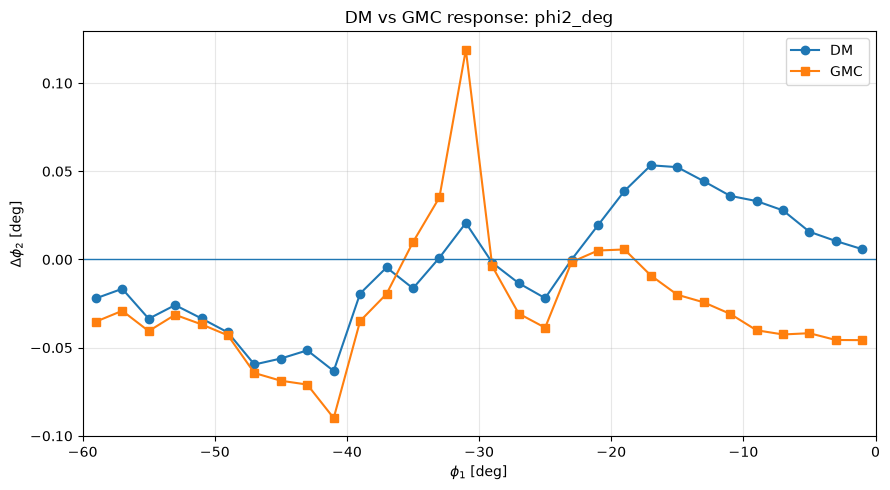

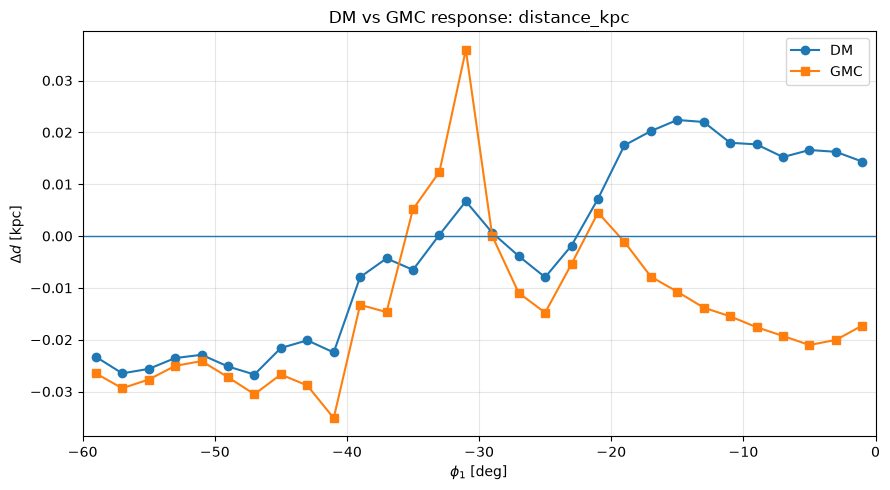

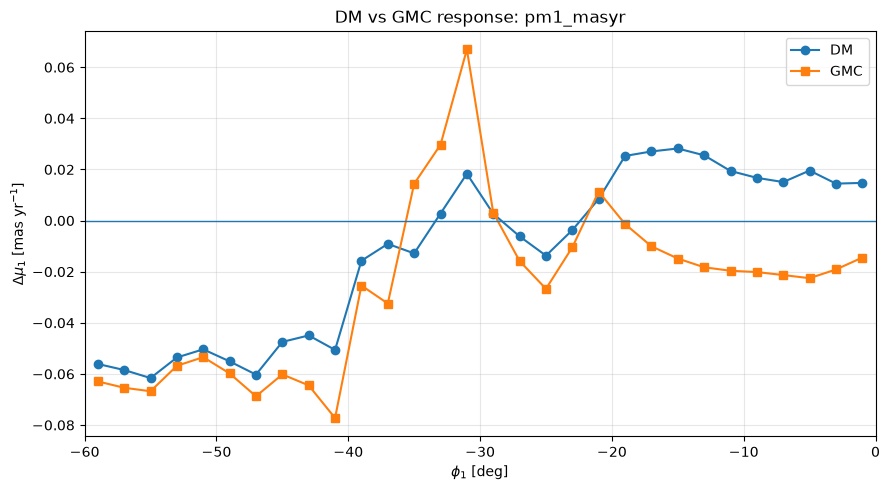

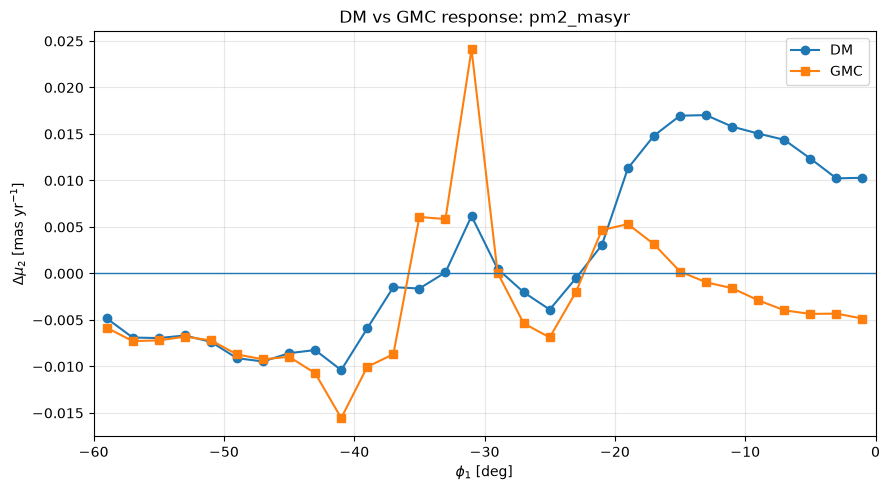

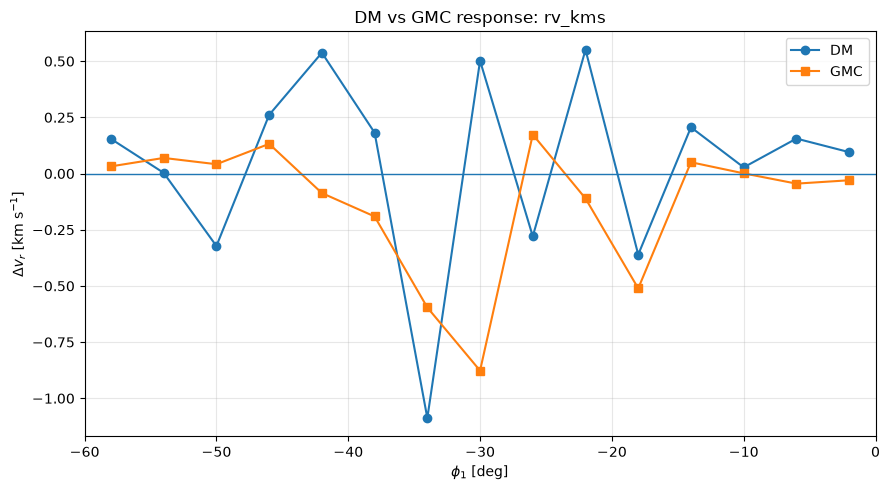


DM–GMC fingerprint plots: PASS


In [56]:
# ============================================================
# L3 — DM vs GMC response fingerprints
# ============================================================

import matplotlib.pyplot as plt

print("=" * 92)
print("PLOTTING DM–GMC RESPONSE FINGERPRINTS")
print("=" * 92)

plot_keys = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]

plot_labels = {
    "phi2_deg": r"$\Delta\phi_2$ [deg]",
    "distance_kpc": r"$\Delta d$ [kpc]",
    "pm1_masyr": r"$\Delta\mu_1$ [mas yr$^{-1}$]",
    "pm2_masyr": r"$\Delta\mu_2$ [mas yr$^{-1}$]",
    "rv_kms": r"$\Delta v_r$ [km s$^{-1}$]",
}

# ------------------------------------------------------------
# DM response grid
# ------------------------------------------------------------

dm_phi1_plot = np.asarray(dm_phi1, dtype=float)
dm_rv_table_plot = Table.read(DM_DIR / "dm_response_rv_192k.csv", format="ascii.csv")
dm_rv_phi1_plot = np.asarray(dm_rv_table_plot["phi1_deg"], dtype=float)

# ------------------------------------------------------------
# Plot phase-space responses
# ------------------------------------------------------------

for key in plot_keys:

    if key == "rv_kms":
        dm_x = dm_rv_phi1_plot
        dm_response = np.asarray(dm_rv_table_plot["response_rv_kms"], dtype=float)
        gmc_response = np.asarray(gmc_rv_response_4deg["G3"]["response"], dtype=float)
        gmc_x = np.asarray(gmc_rv_response_4deg["G3"]["phi1_deg"], dtype=float)
    else:
        dm_x = dm_phi1_plot
        dm_response = np.asarray(dm_response_table[DM_COLUMN_MAP[key]], dtype=float)
        gmc_response = np.asarray(profiles_gmc_fingerprint[key]["delta"], dtype=float)
        gmc_x = np.asarray(PHI1_CENTERS, dtype=float)

    gmc_valid = (
        np.isfinite(gmc_x)
        & np.isfinite(gmc_response)
    )

    dm_valid = (
        np.isfinite(dm_x)
        & np.isfinite(dm_response)
        & (dm_x >= SCIENCE_LO)
        & (dm_x <= SCIENCE_HI)
        )

    gmc_interp = np.full_like(dm_response, np.nan)
    gmc_interp[dm_valid] = np.interp(dm_x[dm_valid], gmc_x[gmc_valid], gmc_response[gmc_valid])

    valid = (
        dm_valid
        & np.isfinite(gmc_interp)
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        dm_x[valid],
        dm_response[valid],
        marker="o",
        label="DM",
    )

    plt.plot(
        dm_x[valid],
        gmc_interp[valid],
        marker="s",
        label="GMC",
    )

    plt.axhline(
        0.0,
        linewidth=1,
    )

    plt.xlabel(r"$\phi_1$ [deg]")
    plt.ylabel(plot_labels[key])
    plt.title(
        f"DM vs GMC response: {key}"
    )

    plt.xlim(
        SCIENCE_LO,
        SCIENCE_HI,
    )

    plt.grid(
        alpha=0.3,
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

print()
print("DM–GMC fingerprint plots: PASS")

In [57]:
# Kernel-state diagnostic

print("=" * 80)
print("NOTEBOOK KERNEL STATE")
print("=" * 80)

names_to_check = [
    "GMC_SWEEP",
    "gmc_sweep_states",
    "gmc_sweep_production",
    "gmc_sweep_controls",
    "gmc_sweep_observables",
    "gmc_sweep_control_observables",
    "gmc_sweep_responses",
    "gmc_sweep_density_responses",
    "gmc_fingerprint_amplitudes",
    "gmc_shape_correlations",
    "comparison_table",
]

for name in names_to_check:
    print(
        f"{name:<40} "
        f"{'AVAILABLE' if name in globals() else 'MISSING'}"
    )

print()
print("=" * 80)
print("DISK CHECK")
print("=" * 80)

from pathlib import Path

print(
    "Project root:",
    Path.cwd().parent
)

gmc_dir = Path.cwd().parent / "data" / "derived" / "gmc_fingerprint_192k"

print(
    "GMC export directory exists:",
    gmc_dir.exists()
)

if gmc_dir.exists():
    print("\nFiles currently in GMC directory:")
    for p in sorted(gmc_dir.iterdir()):
        print(
            f"  {p.name:<40} "
            f"{p.stat().st_size / 1024**2:.2f} MB"
        )

NOTEBOOK KERNEL STATE
GMC_SWEEP                                AVAILABLE
gmc_sweep_states                         AVAILABLE
gmc_sweep_production                     AVAILABLE
gmc_sweep_controls                       AVAILABLE
gmc_sweep_observables                    AVAILABLE
gmc_sweep_control_observables            AVAILABLE
gmc_sweep_responses                      AVAILABLE
gmc_sweep_density_responses              AVAILABLE
gmc_fingerprint_amplitudes               AVAILABLE
gmc_shape_correlations                   AVAILABLE
comparison_table                         AVAILABLE

DISK CHECK
Project root: /home/darxsouls/research/stellar_streams
GMC export directory exists: True

Files currently in GMC directory:
  S_GMC_G1_192k.npz                        12.16 MB
  S_GMC_G2_192k.npz                        12.16 MB
  S_GMC_G3_192k.npz                        12.16 MB
  S_GMC_G4_192k.npz                        12.16 MB
  S_GMC_G5_192k.npz                        12.16 MB
  S_control_G1_192k.n

In [58]:
# ============================================================
# M — Export frozen GMC products
# ============================================================

print("=" * 92)
print("EXPORTING FROZEN GMC PRODUCTS")
print("=" * 92)

GMC_CASE_NAMES = [case["case"] for case in GMC_SWEEP]

# ------------------------------------------------------------
# 0. Ensure export directory exists
# ------------------------------------------------------------

GMC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 1. Production streams and matched controls
# ------------------------------------------------------------

for case_name in GMC_CASE_NAMES:

    np.savez_compressed(
        GMC_DIR / f"S_GMC_{case_name}_192k.npz",
        **gmc_sweep_production[case_name],
    )

    np.savez_compressed(
        GMC_DIR / f"S_control_{case_name}_192k.npz",
        **gmc_sweep_controls[case_name],
    )


# ------------------------------------------------------------
# 2. Canonical G3 phase-space response
#
# This is retained for the DM ↔ GMC comparison.
# Primary observables use the 2-degree grid.
# ------------------------------------------------------------

phase_space_rows = []

for i, phi1 in enumerate(PHI1_CENTERS):

    row = {
        "phi1_deg": float(phi1),
    }

    for key in PRIMARY_OBSERVABLES:

        row[f"response_{key}"] = float(
            profiles_gmc_fingerprint[key]["delta"][i]
        )

    phase_space_rows.append(row)


gmc_phase_space_file = (
    GMC_DIR / "gmc_phase_space_responses_192k.csv"
)

Table(rows=phase_space_rows).write(
    gmc_phase_space_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 3. Complete G1–G5 phase-space response sweep
# ------------------------------------------------------------

sweep_response_rows = []

for case_name in GMC_CASE_NAMES:

    case_response = gmc_sweep_responses[case_name]

    for i, phi1 in enumerate(PHI1_CENTERS):

        row = {
            "case": case_name,
            "phi1_deg": float(phi1),
        }

        for key in PRIMARY_OBSERVABLES:

            row[f"response_{key}"] = float(
                case_response[key]["response"][i]
            )

            row[f"valid_{key}"] = bool(
                case_response[key]["valid"][i]
            )

        sweep_response_rows.append(row)


gmc_sweep_response_file = (
    GMC_DIR / "gmc_sweep_responses_192k.csv"
)

Table(rows=sweep_response_rows).write(
    gmc_sweep_response_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 4. Complete G1–G5 radial-velocity response
#
# RV uses the dedicated 4-degree grid.
# ------------------------------------------------------------

rv_rows = []

for case_name in GMC_CASE_NAMES:

    rv_case = gmc_rv_response_4deg[case_name]

    for phi1, response, valid in zip(
        rv_case["phi1_deg"],
        rv_case["response"],
        rv_case["valid"],
    ):

        rv_rows.append({
            "case": case_name,
            "phi1_deg": float(phi1),
            "response_rv_kms": (
                float(response)
                if valid and np.isfinite(response)
                else np.nan
            ),
            "valid": bool(valid),
        })


gmc_rv_response_file = (
    GMC_DIR / "gmc_rv_response_192k.csv"
)

Table(rows=rv_rows).write(
    gmc_rv_response_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 5. Density responses: G1–G5, 2-degree grid
# ------------------------------------------------------------

density_rows = []

for case_name in GMC_CASE_NAMES:

    density_case = (
        gmc_sweep_density_responses[case_name]
    )

    for i, phi1 in enumerate(PHI1_CENTERS):

        density_rows.append({
            "case": case_name,
            "phi1_deg": float(phi1),
            "delta_ln_density": float(
                density_case["response"][i]
            ),
            "n_gmc": int(
                density_case["density_gmc"][i]
            ),
            "n_control": int(
                density_case["density_control"][i]
            ),
            "valid": bool(
                density_case["valid"][i]
            ),
        })


gmc_density_file = (
    GMC_DIR / "gmc_density_responses_192k.csv"
)

Table(rows=density_rows).write(
    gmc_density_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 6. Fingerprint amplitudes
#
# Includes:
#   phi2
#   distance
#   pm1
#   pm2
#   RV
#   density
# ------------------------------------------------------------

amplitude_rows = []

for case_name in GMC_CASE_NAMES:

    values = gmc_fingerprint_amplitudes[
        case_name
    ]

    amplitude_rows.append({
        "case": case_name,
        "phi2_deg": float(values["phi2_deg"]),
        "distance_kpc": float(values["distance_kpc"]),
        "pm1_masyr": float(values["pm1_masyr"]),
        "pm2_masyr": float(values["pm2_masyr"]),
        "rv_kms": float(values["rv_kms"]),
        "density_log": float(values["density_log"]),
    })


gmc_amplitude_file = (
    GMC_DIR / "gmc_fingerprint_amplitudes_192k.csv"
)

Table(rows=amplitude_rows).write(
    gmc_amplitude_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 7. Response-shape correlations
#
# Primary observables: 2-degree grid
# RV: 4-degree grid
# ------------------------------------------------------------

shape_rows = []

for observable, matrix in gmc_shape_correlations.items():

    grid_width = (
        4.0
        if observable == "rv_kms"
        else 2.0
    )

    for i, case_i in enumerate(GMC_CASE_NAMES):

        for j, case_j in enumerate(GMC_CASE_NAMES):

            shape_rows.append({
                "observable": observable,
                "bin_width_deg": grid_width,
                "case_i": case_i,
                "case_j": case_j,
                "correlation": float(
                    matrix[i, j]
                ),
            })


gmc_shape_file = (
    GMC_DIR / "gmc_response_shape_comparison_192k.csv"
)

Table(rows=shape_rows).write(
    gmc_shape_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 8. DM–GMC response comparison
# ------------------------------------------------------------

comparison_file = (
    GMC_DIR / "dm_gmc_response_comparison_192k.csv"
)

comparison_table.write(
    comparison_file,
    format="ascii.csv",
    overwrite=True,
)


# ------------------------------------------------------------
# 9. Optional downstream comparison products
# ------------------------------------------------------------

if "multidimensional_distance_table" in globals():

    multidimensional_distance_table.write(
        GMC_DIR /
        "dm_gmc_multidimensional_distance_192k.csv",
        format="ascii.csv",
        overwrite=True,
    )


if "ablation_table" in globals():

    ablation_table.write(
        GMC_DIR /
        "dm_gmc_information_ablation_192k.csv",
        format="ascii.csv",
        overwrite=True,
    )


# ------------------------------------------------------------
# 10. Resolution-convergence product
# ------------------------------------------------------------

convergence_file = (
    GMC_DIR /
    "gmc_resolution_convergence_192k.json"
)

with open(
    convergence_file,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        {
            "production_particles": 192064,
            "comparison_particles": 96032,
            "dt_myr": 0.5,
            "release_cadence_myr": 0.5,
            "stripping_duration_myr": 1500.0,
            "random_seed": GMC_RANDOM_SEED,
            "main_bin_width_deg": 2.0,
            "rv_bin_width_deg": 4.0,
            "canonical_rv_convergence_case": "G3",
            "results": gmc_convergence_rows,
        },
        f,
        indent=2,
    )


# ------------------------------------------------------------
# 11. Frozen metadata
# ------------------------------------------------------------

metadata = {
    "project": "stellar_streams",

    "experiment": {
        "name": "GD-1 GMC perturbation fingerprint",
        "notebook": "04_gmc_perturbation_engine",
        "description": (
            "Production GD-1-like stellar-stream "
            "perturbations from compact Plummer "
            "giant molecular cloud perturbers."
        ),
    },

    "numerical_configuration": {
        "n_particles": 192064,
        "convergence_particles": 96032,
        "dt_myr": 0.5,
        "release_cadence_myr": 0.5,
        "stripping_duration_myr": 1500.0,
        "random_seed": int(GMC_RANDOM_SEED),
        "integrator": "leapfrog",
    },

    "progenitor": {
        "mass_msun": float(
            M_PROG.to_value(u.Msun)
        ),
        "half_mass_radius_pc": float(
            R_HALF.to_value(u.pc)
        ),
        "plummer_b_kpc": float(
            PLUMMER_B.to_value(u.kpc)
        ),
    },

    "galactic_potential": {
        "name": "MilkyWayPotential",
        "version": "v2",
    },

    "stream_frame": "GD1Koposov10",

    "encounter": {
        "relative_speed_kms": float(
            GMC_REL_SPEED.to_value(u.km / u.s)
        ),
        "encounter_time_myr": float(
            GMC_T_ENCOUNTER.to_value(u.Myr)
        ),
    },

    "canonical_case": "G3",

    "gmc_sweep": [
        {
            "case": case["case"],
            "mass_msun": float(case["mass_Msun"]),
            "plummer_scale_kpc": float(case["scale_kpc"]),
            "impact_parameter_kpc": float(case["impact_kpc"]),
            "impulse_ratio_to_dm": float(
                impulse_scale(
                    case["mass_Msun"] * u.Msun,
                    case["impact_kpc"] * u.kpc,
                    case["scale_kpc"] * u.kpc,
                ) / I_DM
            ),
        }
        for case in GMC_SWEEP
    ],

    "analysis": {
        "phi1_min_deg": float(SCIENCE_LO),
        "phi1_max_deg": float(SCIENCE_HI),
        "phi1_bin_width_deg": 2.0,
        "n_phi1_bins": int(len(PHI1_CENTERS)),
        "rv_bin_width_deg": 4.0,
        "n_rv_bins": int(len(RV_CENTERS)),
        "robust_width": "1.4826 * MAD",
        "density_response": (
            "ln(N_GMC / N_control)"
        ),
        "phase_space_response": (
            "GMC - matched control"
        ),
        "rv_convergence_case": "G3",
    },

    "files": {
        "phase_space_canonical_G3":
            "gmc_phase_space_responses_192k.csv",
        "sweep_responses":
            "gmc_sweep_responses_192k.csv",
        "rv_responses":
            "gmc_rv_response_192k.csv",
        "density":
            "gmc_density_responses_192k.csv",
        "amplitudes":
            "gmc_fingerprint_amplitudes_192k.csv",
        "shape_comparison":
            "gmc_response_shape_comparison_192k.csv",
        "resolution_convergence":
            "gmc_resolution_convergence_192k.json",
        "dm_gmc_comparison":
            "dm_gmc_response_comparison_192k.csv",
        "metadata":
            "metadata.json",
    },
}

with open(
    GMC_DIR / "metadata.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=2,
    )


# ------------------------------------------------------------
# 12. Final export summary
# ------------------------------------------------------------

print()
print("Exported GMC products:")

for path in sorted(GMC_DIR.iterdir()):

    print(
        f"  {path.name}"
    )

print()
print("=" * 92)
print("GMC PRODUCT EXPORT COMPLETE")
print("=" * 92)

EXPORTING FROZEN GMC PRODUCTS

Exported GMC products:
  S_GMC_G1_192k.npz
  S_GMC_G2_192k.npz
  S_GMC_G3_192k.npz
  S_GMC_G4_192k.npz
  S_GMC_G5_192k.npz
  S_control_G1_192k.npz
  S_control_G2_192k.npz
  S_control_G3_192k.npz
  S_control_G4_192k.npz
  S_control_G5_192k.npz
  dm_gmc_response_comparison_192k.csv
  gmc_density_responses_192k.csv
  gmc_fingerprint_amplitudes_192k.csv
  gmc_phase_space_responses_192k.csv
  gmc_resolution_convergence_192k.json
  gmc_response_shape_comparison_192k.csv
  gmc_rv_response_192k.csv
  gmc_sweep_responses_192k.csv
  metadata.json

GMC PRODUCT EXPORT COMPLETE


In [59]:
# ------------------------------------------------------------
# Diagnose the actual GMC metadata file being validated
# ------------------------------------------------------------

from pathlib import Path
import json

print("=" * 70)
print("ACTUAL GMC METADATA FILE")
print("=" * 70)

print("GMC_DIR:")
print(GMC_DIR)

metadata_path = GMC_DIR / "metadata.json"

print("\nMetadata path:")
print(metadata_path)

print("\nExists:")
print(metadata_path.exists())

with open(metadata_path, "r") as f:
    metadata_debug = json.load(f)

print("\nTop-level keys:")
print(list(metadata_debug.keys()))

print("\nFull metadata:")
print(json.dumps(metadata_debug, indent=2))

ACTUAL GMC METADATA FILE
GMC_DIR:
/home/darxsouls/research/stellar_streams/data/derived/gmc_fingerprint_192k

Metadata path:
/home/darxsouls/research/stellar_streams/data/derived/gmc_fingerprint_192k/metadata.json

Exists:
True

Top-level keys:
['project', 'experiment', 'numerical_configuration', 'progenitor', 'galactic_potential', 'stream_frame', 'encounter', 'canonical_case', 'gmc_sweep', 'analysis', 'files']

Full metadata:
{
  "project": "stellar_streams",
  "experiment": {
    "name": "GD-1 GMC perturbation fingerprint",
    "notebook": "04_gmc_perturbation_engine",
    "description": "Production GD-1-like stellar-stream perturbations from compact Plummer giant molecular cloud perturbers."
  },
  "numerical_configuration": {
    "n_particles": 192064,
    "convergence_particles": 96032,
    "dt_myr": 0.5,
    "release_cadence_myr": 0.5,
    "stripping_duration_myr": 1500.0,
    "random_seed": 314159,
    "integrator": "leapfrog"
  },
  "progenitor": {
    "mass_msun": 20000.0,
   

In [60]:
# ============================================================
# FROZEN GMC PRODUCT VALIDATION — FINAL
# ============================================================

import json
import numpy as np
import pandas as pd

EXPECTED_N = 192_064
EXPECTED_COMPARE_N = 96_032

SCIENCE_LO = -60.0
SCIENCE_HI = 0.0

print("=" * 70)
print("FROZEN GMC PRODUCT VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. File existence
# ------------------------------------------------------------

expected_files = (
    [f"S_GMC_{case}_192k.npz" for case in GMC_CASE_NAMES]
    + [f"S_control_{case}_192k.npz" for case in GMC_CASE_NAMES]
    + [
        "gmc_phase_space_responses_192k.csv",
        "gmc_sweep_responses_192k.csv",
        "gmc_rv_response_192k.csv",
        "gmc_density_responses_192k.csv",
        "gmc_fingerprint_amplitudes_192k.csv",
        "gmc_response_shape_comparison_192k.csv",
        "dm_gmc_response_comparison_192k.csv",
        "gmc_resolution_convergence_192k.json",
        "metadata.json",
    ]
)

missing = [
    f for f in expected_files
    if not (GMC_DIR / f).exists()
]

print(
    f"\nFiles present: "
    f"{len(expected_files) - len(missing)}/{len(expected_files)}"
)

assert not missing, f"Missing files: {missing}"

# ------------------------------------------------------------
# 2. Stream products
# ------------------------------------------------------------

for case in GMC_CASE_NAMES:

    for prefix in ["S_control", "S_GMC"]:

        path = GMC_DIR / f"{prefix}_{case}_192k.npz"

        with np.load(path, allow_pickle=True) as data:

            assert set(data.files) == {
                "stream",
                "progenitor",
                "n_realized",
                "q_rejections",
            }

            stream = data["stream"].item()
            progenitor = data["progenitor"].item()

            n_realized = int(data["n_realized"])
            q_rejections = int(data["q_rejections"])

            assert stream is not None
            assert progenitor is not None
            assert n_realized == EXPECTED_N
            assert q_rejections >= 0

        print(
            f"  PASS {path.name}: "
            f"N={n_realized}, "
            f"q_rejections={q_rejections}"
        )

print("Stream products: PASS")

# ------------------------------------------------------------
# 3. Canonical phase-space response
# ------------------------------------------------------------

phase_df = pd.read_csv(
    GMC_DIR / "gmc_phase_space_responses_192k.csv"
)

assert len(phase_df) == 51

assert list(phase_df.columns) == [
    "phi1_deg",
    "response_phi2_deg",
    "response_distance_kpc",
    "response_pm1_masyr",
    "response_pm2_masyr",
]

# Exact exported 2-degree bin-center grid
expected_phi1 = np.arange(-89.0, 12.0, 2.0)

assert np.allclose(
    phase_df["phi1_deg"].values,
    expected_phi1
)

phase_science = phase_df[
    (phase_df["phi1_deg"] >= SCIENCE_LO)
    & (phase_df["phi1_deg"] <= SCIENCE_HI)
]

assert len(phase_science) == 30

print(
    "Phase-space response: PASS "
    "(51 exported bins; 30 bins in -60 <= phi1 <= 0)"
)

# ------------------------------------------------------------
# 4. Full G1-G5 phase-space sweep
# ------------------------------------------------------------

sweep_df = pd.read_csv(
    GMC_DIR / "gmc_sweep_responses_192k.csv"
)

assert len(sweep_df) == 255
assert set(sweep_df["case"]) == set(GMC_CASE_NAMES)

expected_sweep_cols = {
    "case",
    "phi1_deg",
    "response_phi2_deg",
    "valid_phi2_deg",
    "response_distance_kpc",
    "valid_distance_kpc",
    "response_pm1_masyr",
    "valid_pm1_masyr",
    "response_pm2_masyr",
    "valid_pm2_masyr",
}

assert expected_sweep_cols.issubset(
    sweep_df.columns
)

for case in GMC_CASE_NAMES:

    case_df = sweep_df[
        sweep_df["case"] == case
    ]

    assert len(case_df) == 51

    assert np.allclose(
        case_df["phi1_deg"].values,
        expected_phi1
    )

print(
    "G1-G5 phase-space sweep: PASS "
    "(255 rows = 5 × 51)"
)

# ------------------------------------------------------------
# 5. RV response
# ------------------------------------------------------------

rv_df = pd.read_csv(
    GMC_DIR / "gmc_rv_response_192k.csv"
)

assert len(rv_df) == 130
assert set(rv_df["case"]) == set(GMC_CASE_NAMES)

for case in GMC_CASE_NAMES:

    case_df = rv_df[
        rv_df["case"] == case
    ]

    assert len(case_df) == 26

    expected_rv_phi1 = np.arange(-88.0, 16.0, 4.0)

    assert np.allclose(
        case_df["phi1_deg"].values,
        expected_rv_phi1
    )

assert "valid" in rv_df.columns

print(
    "G1-G5 RV response: PASS "
    "(130 rows = 5 × 26; 4-degree grid)"
)

# ------------------------------------------------------------
# 6. Density response
# ------------------------------------------------------------

density_df = pd.read_csv(
    GMC_DIR / "gmc_density_responses_192k.csv"
)

assert len(density_df) == 255
assert set(density_df["case"]) == set(GMC_CASE_NAMES)

required_density_cols = {
    "case",
    "phi1_deg",
    "delta_ln_density",
    "n_gmc",
    "n_control",
    "valid",
}

assert required_density_cols.issubset(
    density_df.columns
)

for case in GMC_CASE_NAMES:

    case_df = density_df[
        density_df["case"] == case
    ]

    assert len(case_df) == 51

    assert np.allclose(
        case_df["phi1_deg"].values,
        expected_phi1
    )

print(
    "G1-G5 density response: PASS "
    "(255 rows = 5 × 51)"
)

# ------------------------------------------------------------
# 7. Fingerprint amplitudes
# ------------------------------------------------------------

amp_df = pd.read_csv(
    GMC_DIR / "gmc_fingerprint_amplitudes_192k.csv"
)

assert len(amp_df) == 5
assert set(amp_df["case"]) == set(GMC_CASE_NAMES)

required_amp_cols = {
    "case",
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
    "density_log",
}

assert required_amp_cols.issubset(
    amp_df.columns
)

print("Fingerprint amplitudes: PASS")

# ------------------------------------------------------------
# 8. Response-shape comparison
# ------------------------------------------------------------

shape_df = pd.read_csv(
    GMC_DIR / "gmc_response_shape_comparison_192k.csv"
)

# 5 observables × 5 × 5 ordered case pairs
assert len(shape_df) == 125

assert set(shape_df["observable"]) == {
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
}

assert set(shape_df["case_i"]) == set(GMC_CASE_NAMES)
assert set(shape_df["case_j"]) == set(GMC_CASE_NAMES)

# Each observable should contain the full 5 × 5 comparison matrix
for observable in shape_df["observable"].unique():

    obs_df = shape_df[
        shape_df["observable"] == observable
    ]

    assert len(obs_df) == 25

    assert set(
        zip(obs_df["case_i"], obs_df["case_j"])
    ) == {
        (ci, cj)
        for ci in GMC_CASE_NAMES
        for cj in GMC_CASE_NAMES
    }

# Main observables use 2-degree bins
for observable in [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
]:

    vals = shape_df.loc[
        shape_df["observable"] == observable,
        "bin_width_deg"
    ].unique()

    assert len(vals) == 1
    assert np.isclose(vals[0], 2.0)

# RV uses the dedicated 4-degree grid
rv_shape = shape_df[
    shape_df["observable"] == "rv_kms"
]

assert len(rv_shape) == 25
assert np.allclose(
    rv_shape["bin_width_deg"].unique(),
    [4.0]
)

# All correlations must be finite and lie in [-1, 1]
assert np.isfinite(
    shape_df["correlation"]
).all()

assert (
    (shape_df["correlation"] >= -1.0)
    & (shape_df["correlation"] <= 1.0)
).all()

print(
    "Response-shape comparison: PASS "
    "(125 rows = 5 observables × 25 ordered case pairs)"
)

# ------------------------------------------------------------
# 9. DM-GMC comparison
# ------------------------------------------------------------

dm_gmc_df = pd.read_csv(
    GMC_DIR / "dm_gmc_response_comparison_192k.csv"
)

assert len(dm_gmc_df) > 0

print("DM-GMC comparison: PASS")

# ------------------------------------------------------------
# 10. Resolution convergence metadata
# ------------------------------------------------------------

with open(
    GMC_DIR / "gmc_resolution_convergence_192k.json",
    "r"
) as f:
    convergence = json.load(f)

assert convergence["production_particles"] == EXPECTED_N
assert convergence["comparison_particles"] == EXPECTED_COMPARE_N

print("Resolution-convergence metadata: PASS")

# ------------------------------------------------------------
# 11. Main metadata
# ------------------------------------------------------------

with open(
    GMC_DIR / "metadata.json",
    "r"
) as f:
    metadata = json.load(f)

# ------------------------------------------------------------
# Numerical configuration
# ------------------------------------------------------------

numerical = metadata["numerical_configuration"]

assert numerical["n_particles"] == EXPECTED_N
assert numerical["convergence_particles"] == EXPECTED_COMPARE_N

assert np.isclose(
    numerical["dt_myr"],
    0.5,
)

assert np.isclose(
    numerical["release_cadence_myr"],
    0.5,
)

assert np.isclose(
    numerical["stripping_duration_myr"],
    1500.0,
)

assert numerical["random_seed"] == 314159
assert numerical["integrator"] == "leapfrog"

# ------------------------------------------------------------
# Progenitor
# ------------------------------------------------------------

progenitor = metadata["progenitor"]

assert np.isclose(
    progenitor["mass_msun"],
    20000.0,
)

assert np.isclose(
    progenitor["half_mass_radius_pc"],
    20.0,
)

# ------------------------------------------------------------
# Galactic potential and frame
# ------------------------------------------------------------

assert metadata["galactic_potential"]["name"] == (
    "MilkyWayPotential"
)

assert metadata["galactic_potential"]["version"] == "v2"

assert metadata["stream_frame"] == "GD1Koposov10"

# ------------------------------------------------------------
# Encounter configuration
# ------------------------------------------------------------

encounter = metadata["encounter"]

assert np.isclose(
    encounter["relative_speed_kms"],
    300.0,
)

assert np.isclose(
    encounter["encounter_time_myr"],
    -500.0,
)

# ------------------------------------------------------------
# Canonical GMC case
# ------------------------------------------------------------

assert metadata["canonical_case"] == "G3"

# ------------------------------------------------------------
# GMC sweep
# ------------------------------------------------------------

gmc_sweep_metadata = metadata["gmc_sweep"]

assert len(gmc_sweep_metadata) == len(GMC_CASE_NAMES)

assert {
    case["case"]
    for case in gmc_sweep_metadata
} == set(GMC_CASE_NAMES)

# ------------------------------------------------------------
# Analysis configuration
# ------------------------------------------------------------

analysis = metadata["analysis"]

assert np.isclose(
    analysis["phi1_min_deg"],
    -60.0,
)

assert np.isclose(
    analysis["phi1_max_deg"],
    0.0,
)

assert np.isclose(
    analysis["phi1_bin_width_deg"],
    2.0,
)

assert analysis["rv_bin_width_deg"] == 4.0

assert analysis["robust_width"] == "1.4826 * MAD"

assert analysis["density_response"] == (
    "ln(N_GMC / N_control)"
)

assert analysis["phase_space_response"] == (
    "GMC - matched control"
)

assert analysis["rv_convergence_case"] == "G3"

# ------------------------------------------------------------
# Exported file references
# ------------------------------------------------------------

files_meta = metadata["files"]

assert (
    files_meta["phase_space_canonical_G3"]
    == "gmc_phase_space_responses_192k.csv"
)

assert (
    files_meta["sweep_responses"]
    == "gmc_sweep_responses_192k.csv"
)

assert (
    files_meta["rv_responses"]
    == "gmc_rv_response_192k.csv"
)

assert (
    files_meta["density"]
    == "gmc_density_responses_192k.csv"
)

assert (
    files_meta["amplitudes"]
    == "gmc_fingerprint_amplitudes_192k.csv"
)

assert (
    files_meta["shape_comparison"]
    == "gmc_response_shape_comparison_192k.csv"
)

assert (
    files_meta["resolution_convergence"]
    == "gmc_resolution_convergence_192k.json"
)

assert (
    files_meta["dm_gmc_comparison"]
    == "dm_gmc_response_comparison_192k.csv"
)

assert files_meta["metadata"] == "metadata.json"

print("Main metadata: PASS")


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FROZEN GMC PRODUCT VALIDATION: PASS")
print("=" * 70)

FROZEN GMC PRODUCT VALIDATION

Files present: 19/19
  PASS S_control_G1_192k.npz: N=192064, q_rejections=2
  PASS S_GMC_G1_192k.npz: N=192064, q_rejections=2
  PASS S_control_G2_192k.npz: N=192064, q_rejections=2
  PASS S_GMC_G2_192k.npz: N=192064, q_rejections=2
  PASS S_control_G3_192k.npz: N=192064, q_rejections=2
  PASS S_GMC_G3_192k.npz: N=192064, q_rejections=2
  PASS S_control_G4_192k.npz: N=192064, q_rejections=2
  PASS S_GMC_G4_192k.npz: N=192064, q_rejections=2
  PASS S_control_G5_192k.npz: N=192064, q_rejections=2
  PASS S_GMC_G5_192k.npz: N=192064, q_rejections=2
Stream products: PASS
Phase-space response: PASS (51 exported bins; 30 bins in -60 <= phi1 <= 0)
G1-G5 phase-space sweep: PASS (255 rows = 5 × 51)
G1-G5 RV response: PASS (130 rows = 5 × 26; 4-degree grid)
G1-G5 density response: PASS (255 rows = 5 × 51)
Fingerprint amplitudes: PASS
Response-shape comparison: PASS (125 rows = 5 observables × 25 ordered case pairs)
DM-GMC comparison: PASS
Resolution-convergence meta